In [1]:
import os
import re
import glob
import concurrent.futures

import ROOT
import pyhepmc

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm
from pathlib import Path

ROOT.gROOT.ProcessLine('.include /usr/local/Delphes-3.4.2/')
ROOT.gROOT.ProcessLine('.include /usr/local/Delphes-3.4.2/external/')
ROOT.gInterpreter.Declare('#include "/usr/local/Delphes-3.4.2/classes/DelphesClasses.h"')
ROOT.gSystem.Load("/usr/local/Delphes-3.4.2/install/lib/libDelphes")

Welcome to JupyROOT 6.20/08


0

# Common function

In [2]:
Z_MASS = 91.1876
Z_VETO_WINDOW = 15.0


def _is_in_electron_crack(eta):
    aeta = abs(eta)
    return 1.37 < aeta < 1.52


def _build_sr_leptons(event):
    leptons = []
    for e in event.Electron:
        if e.PT > 27.0 and abs(e.Eta) < 2.47:
            if _is_in_electron_crack(e.Eta):
                continue
            vec = ROOT.TLorentzVector()
            vec.SetPtEtaPhiM(e.PT, e.Eta, e.Phi, 0.000511)
            leptons.append({"p4": vec, "charge": e.Charge, "flavor": "e"})

    for m in event.Muon:
        if m.PT > 27.0 and abs(m.Eta) < 2.5:
            vec = ROOT.TLorentzVector()
            vec.SetPtEtaPhiM(m.PT, m.Eta, m.Phi, 0.10566)
            leptons.append({"p4": vec, "charge": m.Charge, "flavor": "mu"})

    leptons.sort(key=lambda x: x["p4"].Pt(), reverse=True)
    return leptons


def _build_wz_cr_leptons(event):
    leptons = []
    for e in event.Electron:
        if e.PT > 15.0 and abs(e.Eta) < 2.47:
            if _is_in_electron_crack(e.Eta):
                continue
            vec = ROOT.TLorentzVector()
            vec.SetPtEtaPhiM(e.PT, e.Eta, e.Phi, 0.000511)
            leptons.append({"p4": vec, "charge": e.Charge, "flavor": "e"})

    for m in event.Muon:
        if m.PT > 15.0 and abs(m.Eta) < 2.5:
            vec = ROOT.TLorentzVector()
            vec.SetPtEtaPhiM(m.PT, m.Eta, m.Phi, 0.10566)
            leptons.append({"p4": vec, "charge": m.Charge, "flavor": "mu"})

    leptons.sort(key=lambda x: x["p4"].Pt(), reverse=True)
    return leptons


def _build_sr_jets(event):
    jets = []
    for j in event.Jet:
        if abs(j.Eta) < 4.5 and j.PT > 25.0:
            vec = ROOT.TLorentzVector()
            vec.SetPtEtaPhiM(j.PT, j.Eta, j.Phi, j.Mass)
            btag = bool(j.BTag) if hasattr(j, "BTag") else False
            jets.append({"p4": vec, "btag": btag})

    jets.sort(key=lambda x: x["p4"].Pt(), reverse=True)
    return jets


def _has_btagged_veto_jet(event):
    # b-tag veto only considers jets with pT > 20 GeV and |eta| < 2.5
    for j in event.Jet:
        if j.PT > 20.0 and abs(j.Eta) < 2.5:
            if bool(j.BTag) if hasattr(j, "BTag") else False:
                return True
    return False


def _pass_region_cuts(event, mjj_min=None, mjj_max=None, return_objects=False):
    # --- A. 輕子篩選 (Leptons) ---
    leptons = _build_sr_leptons(event)

    # Exactly two signal leptons
    if len(leptons) != 2:
        return (0, None) if return_objects else 0

    l1, l2 = leptons[0], leptons[1]
    if l1["charge"] != l2["charge"]:
        return (0, None) if return_objects else 0

    ll_p4 = l1["p4"] + l2["p4"]
    if ll_p4.M() <= 20.0:
        return (0, None) if return_objects else 0

    # ee channel: both electrons must satisfy |eta| < 1.37, and apply Z-veto
    is_ee_channel = l1["flavor"] == "e" and l2["flavor"] == "e"
    if is_ee_channel:
        if abs(l1["p4"].Eta()) >= 1.37 or abs(l2["p4"].Eta()) >= 1.37:
            return (0, None) if return_objects else 0
        if abs(ll_p4.M() - Z_MASS) <= Z_VETO_WINDOW:
            return (0, None) if return_objects else 0

    # --- B. 遺失橫向動量 (MET) ---
    if event.MissingET.GetSize() == 0:
        return (1, None) if return_objects else 1
    met = event.MissingET[0]
    if met.MET <= 30.0:
        return (1, None) if return_objects else 1

    # --- C. 噴流篩選 (Jets) ---
    jet_objs = _build_sr_jets(event)
    if len(jet_objs) < 2:
        return (2, None) if return_objects else 2

    # No b-tagged veto jets with pT > 20 GeV and |eta| < 2.5
    if _has_btagged_veto_jet(event):
        return (2, None) if return_objects else 2

    j1, j2 = jet_objs[0]["p4"], jet_objs[1]["p4"]
    if j1.Pt() <= 65.0:
        return (2, None) if return_objects else 2
    if j2.Pt() <= 35.0:
        return (2, None) if return_objects else 2

    m_jj = (j1 + j2).M()
    if mjj_min is not None and m_jj <= mjj_min:
        return (2, None) if return_objects else 2
    if mjj_max is not None and m_jj >= mjj_max:
        return (2, None) if return_objects else 2

    if abs(j1.Rapidity() - j2.Rapidity()) <= 2.0:
        return (2, None) if return_objects else 2

    if return_objects:
        return 3, {
            "leptons": leptons,
            "ll_p4": ll_p4,
            "met": met,
            "jets": [j["p4"] for j in jet_objs],
        }
    return 3


def pass_SR_cuts(event, return_objects=False):
    """
    SR: 和基準選取相同，並要求 m_jj > 500 GeV。
    """
    return _pass_region_cuts(
        event,
        mjj_min=500.0,
        mjj_max=None,
        return_objects=return_objects,
    )


def pass_low_mjj_cr_cuts(event, return_objects=False):
    """
    Low-mjj Control Region:
    與 SR 定義一致，但改為 200 GeV < m_jj < 500 GeV。
    """
    return _pass_region_cuts(
        event,
        mjj_min=200.0,
        mjj_max=500.0,
        return_objects=return_objects,
    )


def pass_WZ_CR_cuts(event, return_objects=False):
    """
    WZ Control Region:
    - 與 (Low-mjj + SR) 的噴流/MET/b-veto 定義一致
    - 三個 signal leptons，且第三個 lepton pT > 15 GeV
    - 前兩個 lepton 仍要求 pT > 27 GeV
    - m_lll > 106 GeV
    """
    leptons = _build_wz_cr_leptons(event)

    # Two signal leptons + one additional third signal lepton
    if len(leptons) != 3:
        return (0, None) if return_objects else 0

    l1, l2, l3 = leptons[0], leptons[1], leptons[2]

    # Keep SR-like requirement: the two leading leptons are same-sign
    if l1["charge"] != l2["charge"]:
        return (0, None) if return_objects else 0

    # Leading two leptons still need SR-like pT threshold
    if l1["p4"].Pt() <= 27.0 or l2["p4"].Pt() <= 27.0:
        return (0, None) if return_objects else 0

    # The additional third signal lepton threshold
    if l3["p4"].Pt() <= 15.0:
        return (0, None) if return_objects else 0

    # At least one lepton pair satisfies m_ll >= 20 GeV
    ll_pairs = [
        leptons[0]["p4"] + leptons[1]["p4"],
        leptons[0]["p4"] + leptons[2]["p4"],
        leptons[1]["p4"] + leptons[2]["p4"],
    ]
    n_pairs_mll20 = sum(1 for p4 in ll_pairs if p4.M() >= 20.0)
    if n_pairs_mll20 < 1:
        return (0, None) if return_objects else 0

    # ee requirement (applied to the leading same-sign pair if both are electrons)
    is_ee_channel = l1["flavor"] == "e" and l2["flavor"] == "e"
    ll_p4 = l1["p4"] + l2["p4"]
    if is_ee_channel:
        if abs(l1["p4"].Eta()) >= 1.37 or abs(l2["p4"].Eta()) >= 1.37:
            return (0, None) if return_objects else 0
        if abs(ll_p4.M() - Z_MASS) <= Z_VETO_WINDOW:
            return (0, None) if return_objects else 0

    # Tri-lepton invariant mass
    lll_p4 = l1["p4"] + l2["p4"] + l3["p4"]
    if lll_p4.M() <= 106.0:
        return (0, None) if return_objects else 0

    # MET
    if event.MissingET.GetSize() == 0:
        return (1, None) if return_objects else 1
    met = event.MissingET[0]
    if met.MET <= 30.0:
        return (1, None) if return_objects else 1

    # Jets + b-veto + merged Low-mjj/SR region jet requirements
    jet_objs = _build_sr_jets(event)
    if len(jet_objs) < 2:
        return (2, None) if return_objects else 2

    if _has_btagged_veto_jet(event):
        return (2, None) if return_objects else 2

    j1, j2 = jet_objs[0]["p4"], jet_objs[1]["p4"]
    if j1.Pt() <= 65.0:
        return (2, None) if return_objects else 2
    if j2.Pt() <= 35.0:
        return (2, None) if return_objects else 2

    # merged Low-mjj + SR definition
    if (j1 + j2).M() <= 200.0:
        return (2, None) if return_objects else 2

    if abs(j1.Rapidity() - j2.Rapidity()) <= 2.0:
        return (2, None) if return_objects else 2

    if return_objects:
        return 3, {
            "leptons": leptons,
            "ll_p4": ll_p4,
            "lll_p4": lll_p4,
            "met": met,
            "jets": [j["p4"] for j in jet_objs],
        }
    return 3

In [3]:
def _get_cut_function(cut_func_name):
    """Get cut function by name to enable pickling across processes."""
    cut_functions = {
        'pass_SR_cuts': pass_SR_cuts,
        'pass_low_mjj_cr_cuts': pass_low_mjj_cr_cuts,
        'pass_WZ_CR_cuts': pass_WZ_CR_cuts,
    }
    if cut_func_name not in cut_functions:
        raise ValueError(f"Unknown cut function: {cut_func_name}")
    return cut_functions[cut_func_name]


def _selection_cut_on_entry_range(tree, start_index, end_index, cut_func):
    """Core selection loop over a half-open entry range [start_index, end_index)."""
    cutflow = {
        "Total": 0,
        "lepton cut": 0,
        "MET cut": 0,
        "Jet cut": 0,
    }

    deta_ll, dphi_jj, mT = [], [], []
    pt_j2, m_jj, deltaR_jj = [], [], []

    for entry_index in range(start_index, end_index):
        tree.GetEntry(entry_index)
        cutflow["Total"] += 1

        stage, region_objects = cut_func(tree, return_objects=True)
        if stage >= 1:
            cutflow["lepton cut"] += 1
        if stage >= 2:
            cutflow["MET cut"] += 1
        if stage >= 3:
            cutflow["Jet cut"] += 1

        if stage < 3:
            continue

        leptons = region_objects["leptons"]
        l1, l2 = leptons[0], leptons[1]
        ll_p4 = region_objects["ll_p4"]
        met = region_objects["met"]
        jets = region_objects["jets"]
        j1, j2 = jets[0], jets[1]

        deta_ll.append(abs(l1["p4"].Eta() - l2["p4"].Eta()))
        dphi_jj.append(abs(j1.DeltaPhi(j2)))

        met_px = met.MET * np.cos(met.Phi)
        met_py = met.MET * np.sin(met.Phi)
        Et_ll = np.sqrt(ll_p4.Pt() ** 2 + ll_p4.M() ** 2)
        px_tot = ll_p4.Px() + met_px
        py_tot = ll_p4.Py() + met_py
        mT_sq = (Et_ll + met.MET) ** 2 - (px_tot ** 2 + py_tot ** 2)
        mT.append(np.sqrt(mT_sq) if mT_sq > 0 else 0.0)

        pt_j2.append(j2.Pt())
        m_jj.append((j1 + j2).M())
        deltaR_jj.append(j1.DeltaR(j2))

    return {
        "cutflow": cutflow,
        "deta_ll": np.array(deta_ll),
        "dphi_jj": np.array(dphi_jj),
        "mT": np.array(mT),
        "pt_j2": np.array(pt_j2),
        "m_jj": np.array(m_jj),
        "deltaR_jj": np.array(deltaR_jj),
    }


def _selection_cut_with_region(tree, cut_func):
    n_entries = int(tree.GetEntries())
    return _selection_cut_on_entry_range(tree, 0, n_entries, cut_func)


def _selection_cut_chunk(root_path, start, end, cut_func_name):
    cut_func = _get_cut_function(cut_func_name)

    f = ROOT.TFile(root_path)
    if not f or f.IsZombie():
        raise RuntimeError(f"Cannot open ROOT file: {root_path}")

    tree = f.Get('Delphes')
    if tree is None:
        f.Close()
        raise RuntimeError(f"Cannot find Delphes tree in {root_path}")

    n_entries = int(tree.GetEntries())
    i0 = max(0, int(start))
    i1 = min(n_entries, int(end))
    results = _selection_cut_on_entry_range(tree, i0, i1, cut_func)
    f.Close()
    return results


def _merge_selection_results(results_list):
    if not results_list:
        return {
            "cutflow": {"Total": 0, "lepton cut": 0, "MET cut": 0, "Jet cut": 0},
            "deta_ll": np.array([]),
            "dphi_jj": np.array([]),
            "mT": np.array([]),
            "pt_j2": np.array([]),
            "m_jj": np.array([]),
            "deltaR_jj": np.array([]),
        }

    merged_cutflow = {
        "Total": 0,
        "lepton cut": 0,
        "MET cut": 0,
        "Jet cut": 0,
    }

    arrays_to_merge = {
        "deta_ll": [],
        "dphi_jj": [],
        "mT": [],
        "pt_j2": [],
        "m_jj": [],
        "deltaR_jj": [],
    }

    for result in results_list:
        for key in merged_cutflow:
            merged_cutflow[key] += result["cutflow"][key]
        for key in arrays_to_merge:
            arr = result.get(key, np.array([]))
            if arr.size > 0:
                arrays_to_merge[key].append(arr)

    return {
        "cutflow": merged_cutflow,
        "deta_ll": np.concatenate(arrays_to_merge["deta_ll"]) if arrays_to_merge["deta_ll"] else np.array([]),
        "dphi_jj": np.concatenate(arrays_to_merge["dphi_jj"]) if arrays_to_merge["dphi_jj"] else np.array([]),
        "mT": np.concatenate(arrays_to_merge["mT"]) if arrays_to_merge["mT"] else np.array([]),
        "pt_j2": np.concatenate(arrays_to_merge["pt_j2"]) if arrays_to_merge["pt_j2"] else np.array([]),
        "m_jj": np.concatenate(arrays_to_merge["m_jj"]) if arrays_to_merge["m_jj"] else np.array([]),
        "deltaR_jj": np.concatenate(arrays_to_merge["deltaR_jj"]) if arrays_to_merge["deltaR_jj"] else np.array([]),
    }


def selection_cut_parallel(sample_groups, cut_func_name, num_workers=None, chunks_per_file=1):
    if num_workers is None:
        num_workers = max(1, (os.cpu_count() or 1) // 2)
    num_workers = max(1, int(num_workers))
    chunks_per_file = max(1, int(chunks_per_file))

    grouped_results = {}
    group_items = list(sample_groups.items())

    for group_idx, (group_name, root_files) in enumerate(group_items, 1):
        print(f"\n[{group_idx}/{len(group_items)}] {group_name}: Processing {len(root_files)} file(s) with {num_workers} worker(s), {chunks_per_file} chunk(s) per file...")

        tasks = []
        for root_path in root_files:
            f = ROOT.TFile(root_path)
            if f and not f.IsZombie():
                tree = f.Get('Delphes')
                if tree:
                    n_entries = int(tree.GetEntries())
                    chunk_size = max(1, n_entries // chunks_per_file)
                    for chunk_idx in range(chunks_per_file):
                        start = chunk_idx * chunk_size
                        end = (chunk_idx + 1) * chunk_size if chunk_idx < chunks_per_file - 1 else n_entries
                        tasks.append((root_path, start, end))
                f.Close()

        chunk_results = []
        if tasks:
            with concurrent.futures.ProcessPoolExecutor(max_workers=num_workers) as executor:
                futures = {
                    executor.submit(_selection_cut_chunk, root_path, start, end, cut_func_name): (root_path, start, end)
                    for root_path, start, end in tasks
                }
                for future in tqdm(
                    concurrent.futures.as_completed(futures),
                    total=len(futures),
                    desc=f"    {group_name}",
                    leave=True,
                ):
                    try:
                        chunk_results.append(future.result())
                    except Exception as exc:
                        root_path, start, end = futures[future]
                        print(f"  [Error] chunk task failed for {root_path} [{start}, {end}): {exc}")

        merged = _merge_selection_results(chunk_results)
        grouped_results[group_name] = merged
        print(f"  ✓ [{group_name}] done → Total={merged['cutflow']['Total']} events, passed={merged['cutflow']['Jet cut']}")

    return grouped_results

In [4]:
def get_cross_section_from_MG5(banner_path):
    # returns the generated cross section in fb
    banner_path = Path(banner_path)
    with open(banner_path, 'r') as f:
        text = f.read()

    # 支援一般浮點與科學記號，例如 1.23e-03
    match = re.search(r'#\s+Integrated weight \(pb\)\s*:\s*([0-9.eE+-]+)', text)
    if not match:
        raise ValueError(f'Cannot find Integrated weight (pb) in {banner_path}')

    return float(match.group(1)) * 1000.0

In [5]:
def selection_cut_SR(tree):
    return _selection_cut_with_region(tree, pass_SR_cuts)


def selection_cut_low_mjj_CR(tree):
    return _selection_cut_with_region(tree, pass_low_mjj_cr_cuts)


def selection_cut_WZ_CR(tree):
    return _selection_cut_with_region(tree, pass_WZ_CR_cuts)

# MadGraph 

In [5]:
root_file = './MG5/EW_WWjj_LL-WW_cmf-NNPDF30_nlo_as_0118/Events/run_02/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')
results_LL = selection_cut_SR(tree)

root_file = './MG5/EW_WWjj_LT-WW_cmf-NNPDF30_nlo_as_0118/Events/run_02/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')
results_LT = selection_cut_SR(tree)

root_file = './MG5/EW_WWjj_TT-WW_cmf-NNPDF30_nlo_as_0118/Events/run_02/tag_1_delphes_events.root'
f = ROOT.TFile(root_file)
tree = f.Get('Delphes')
results_TT = selection_cut_SR(tree)

100000it [01:43, 964.25it/s]
100000it [01:38, 1010.13it/s]
100000it [01:39, 1009.96it/s]
Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Track read from file ./MG5/EW_WWjj_LL-WW_cmf-NNPDF30_nlo_as_0118/Events/run_02/tag_1_delphes_events.root
   has the same version (=3) as the active class but a different checksum.
   You should update the version to ClassDef(Track,4).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float C; //
Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float Mass; //
Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing fro

In [6]:
np.save('./selection_cut_results/selection_results_EW_WWjj_LL-WW_cmf-NNPDF30_nlo_as_0118.npy', results_LL)
np.save('./selection_cut_results/selection_results_EW_WWjj_LT-WW_cmf-NNPDF30_nlo_as_0118.npy', results_LT)
np.save('./selection_cut_results/selection_results_EW_WWjj_TT-WW_cmf-NNPDF30_nlo_as_0118.npy', results_TT)

In [7]:
LL_selection = np.load('./selection_cut_results/selection_results_EW_WWjj_LL-WW_cmf-NNPDF30_nlo_as_0118.npy', allow_pickle=True).item()
LT_selection = np.load('./selection_cut_results/selection_results_EW_WWjj_LT-WW_cmf-NNPDF30_nlo_as_0118.npy', allow_pickle=True).item()
TT_selection = np.load('./selection_cut_results/selection_results_EW_WWjj_TT-WW_cmf-NNPDF30_nlo_as_0118.npy', allow_pickle=True).item()

In [9]:
print('LL mode')
n_total = LL_selection['cutflow']['Total']
for key, value in LL_selection['cutflow'].items():
    print(f'{key:20} {value:<8} & {value/n_total:8.2f}')

print('LT mode')
n_total = LT_selection['cutflow']['Total']
for key, value in LT_selection['cutflow'].items():
    print(f'{key:20} {value:<8} & {value/n_total:8.2f}')

print('TT mode')
n_total = TT_selection['cutflow']['Total']
for key, value in TT_selection['cutflow'].items():
    print(f'{key:20} {value:<8} & {value/n_total:8.2f}')

LL mode
Total                100000   &     1.00
lepton cut           48899    &     0.49
MET cut              45281    &     0.45
Jet cut              37011    &     0.37
LT mode
Total                100000   &     1.00
lepton cut           50294    &     0.50
MET cut              47187    &     0.47
Jet cut              38739    &     0.39
TT mode
Total                100000   &     1.00
lepton cut           53640    &     0.54
MET cut              50814    &     0.51
Jet cut              41805    &     0.42


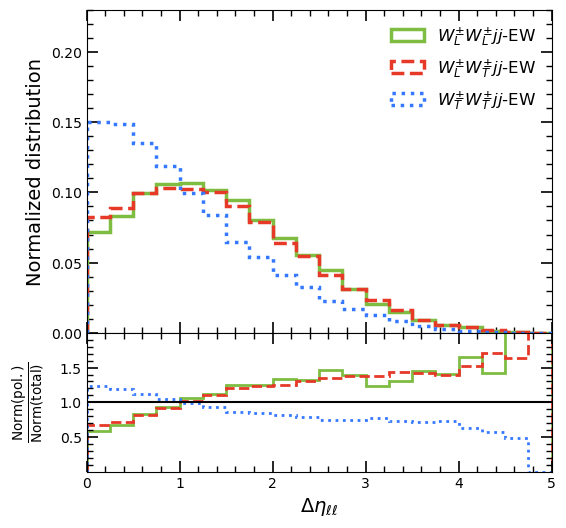

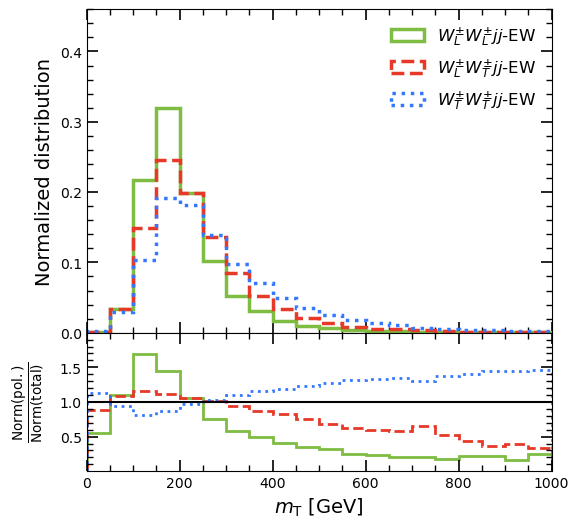

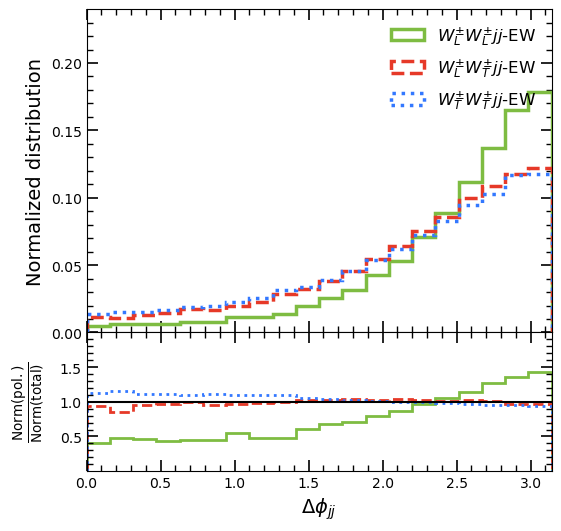

In [ ]:
# ==========================================
# 1. 定義繪圖函數 (處理主圖與比例圖)
# ==========================================
def plot_atlas_variable(ax_main, ax_ratio, data_dict, var_key, bins, val_range, xlabel, ymax):
    
    # 提取三個極化態的資料
    LL_data = data_dict['LL'][var_key]
    LT_data = data_dict['LT'][var_key]
    TT_data = data_dict['TT'][var_key]
    
    # 計算 Histogram 數值 (使用 weights 正規化使得面積/總和 = 1)
    hist_LL, bin_edges = np.histogram(LL_data, bins=bins, range=val_range, weights=np.ones_like(LL_data)/len(LL_data))
    hist_LT, _ = np.histogram(LT_data, bins=bins, range=val_range, weights=np.ones_like(LT_data)/len(LT_data))
    hist_TT, _ = np.histogram(TT_data, bins=bins, range=val_range, weights=np.ones_like(TT_data)/len(TT_data))
    
    # 設定繪圖樣式 (對標 ATLAS 論文的配色與線型)
    styles = {
        'LL': {"color": "#7EBC42", "linestyle": "solid", "label": '$W_L^{\pm}W_L^{\pm}jj$-EW'}, # 亮綠色
        'LT': {"color": "#E63928", "linestyle": "dashed", "label": '$W_L^{\pm}W_T^{\pm}jj$-EW'}, # 紅色虛線
        'TT': {"color": "#3378FF", "linestyle": "dotted", "label": '$W_T^{\pm}W_T^{\pm}jj$-EW'}  # 藍色點線
    }
    
    # --- 繪製上層 Main Pad ---
    # matplotlib 的 step 預設從 bin 的左邊緣開始畫，為了讓最右邊閉合，需要在最後補一個數值
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    ax_main.hist(bin_centers, bins=bin_edges, weights=hist_LL, histtype='step', linewidth=2.5, **styles['LL'])
    ax_main.hist(bin_centers, bins=bin_edges, weights=hist_LT, histtype='step', linewidth=2.5, **styles['LT'])
    ax_main.hist(bin_centers, bins=bin_edges, weights=hist_TT, histtype='step', linewidth=2.5, **styles['TT'])
    
    ax_main.set_xlim(val_range)
    ax_main.set_ylim(0, ymax)
    ax_main.set_ylabel("Normalized distribution", fontsize=14)
    ax_main.tick_params(axis='x', labelbottom=False) # 隱藏 X 軸刻度文字
    
    # 設定刻度向內並啟用小刻度
    ax_main.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, top=True, right=True)
    ax_main.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0, top=True, right=True)
    ax_main.minorticks_on()
    
    # 設定圖例
    ax_main.legend(frameon=False, loc="upper right", fontsize=12)
    
    # --- 計算並繪製下層 Ratio Pad ---
    # 合成 Total SM 形狀 (10% LL + 30% LT + 60% TT)
    hist_total = 0.10 * hist_LL + 0.30 * hist_LT + 0.60 * hist_TT
    
    # 避免除以零
    safe_total = np.where(hist_total == 0, 1e-10, hist_total)
    
    ratio_LL = hist_LL / safe_total
    ratio_LT = hist_LT / safe_total
    ratio_TT = hist_TT / safe_total
    
    # 用 step 畫出 Ratio
    ax_ratio.stairs(ratio_LL, edges=bin_edges, color=styles['LL']["color"], linewidth=2, linestyle=styles['LL']["linestyle"])
    ax_ratio.stairs(ratio_LT, edges=bin_edges, color=styles['LT']["color"], linewidth=2, linestyle=styles['LT']["linestyle"])
    ax_ratio.stairs(ratio_TT, edges=bin_edges, color=styles['TT']["color"], linewidth=2, linestyle=styles['TT']["linestyle"])
    
    # 畫出 y=1 的參考實線
    ax_ratio.axhline(1.0, color='black', linewidth=1.5)
    
    ax_ratio.set_xlim(val_range)
    ax_ratio.set_ylim(0, 2.0)
    ax_ratio.set_xlabel(xlabel, fontsize=14)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Norm(pol.)}}{\mathrm{Norm(total)}}$", fontsize=14, labelpad=10)
    
    # 調整 Y 軸刻度數量避免太擠
    ax_ratio.set_yticks([0.5, 1.0, 1.5])
    
    # 設定刻度向內並啟用小刻度
    ax_ratio.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, top=True, right=True)
    ax_ratio.tick_params(axis='both', which='minor', direction='in', length=4, width=1.0, top=True, right=True)
    ax_ratio.minorticks_on()


# ==========================================
# 2. 準備你的資料 (請將這裡替換成你真實的 numpy 陣列)
# ==========================================

my_data = {
    'LL': LL_selection,
    'LT': LT_selection,
    'TT': TT_selection
}

# ==========================================
# 3. 分別繪製並儲存三張獨立的圖
# ==========================================

variables = [
    {'key': "deta_ll", 'bins': 20, "range": (0, 5.0), 'xlabel': '$\Delta\eta_{\ell\ell}$', 'ymax': 0.23, 'filename': 'deta_ll'},
    {'key': "mT",      'bins': 20, "range": (0, 1000), 'xlabel': '$m_\mathrm{T}$ [GeV]', 'ymax': 0.46, 'filename': 'mT'},
    {'key': "dphi_jj", 'bins': 20, "range": (0, np.pi), 'xlabel': '$\Delta\phi_{jj}$', 'ymax': 0.24, 'filename': 'dphi_jj'},
]

for var_info in variables:
    # 為每個變量創建獨立的圖
    fig = plt.figure(figsize=(6, 6))
    gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3], hspace=0.00)
    
    ax_main = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1])
    
    plot_atlas_variable(
        ax_main=ax_main, 
        ax_ratio=ax_ratio, 
        data_dict=my_data, 
        var_key=var_info['key'], 
        bins=var_info['bins'], 
        val_range=var_info["range"], 
        xlabel=var_info['xlabel'], 
        ymax=var_info['ymax']
    )
    
    # 儲存圖片
    plt.savefig(f"../figures/EW_WWjj_{var_info['filename']}-ww_cmf.pdf", bbox_inches='tight', dpi=300)
    
    plt.show()
    plt.close()

## Evaluate absolute cross-sections

In [11]:
# ==========================================
# 利用 MadGraph5 banner 檔案計算絕對截面積
# ==========================================

# 讀取每個模式的原始截面積 (單位: fb)
sample_dir = Path('./MG5/')
sigma_gen_LL = get_cross_section_from_MG5(sample_dir / 'EW_WWjj_LL-WW_cmf/Events/run_01/run_01_tag_1_banner.txt')
sigma_gen_LT = get_cross_section_from_MG5(sample_dir / 'EW_WWjj_LT-WW_cmf/Events/run_01/run_01_tag_1_banner.txt')
sigma_gen_TT = get_cross_section_from_MG5(sample_dir / 'EW_WWjj_TT-WW_cmf/Events/run_01/run_01_tag_1_banner.txt')

print("=" * 80)
print("生成過程的截面積 (from MadGraph5 banner):")
print("=" * 80)
print(f"LL mode: σ_gen = {sigma_gen_LL:.4f} fb")
print(f"LT mode: σ_gen = {sigma_gen_LT:.4f} fb")
print(f"TT mode: σ_gen = {sigma_gen_TT:.4f} fb")

# ==========================================
# 計算每個 cut 階段的截面積並製作表格
# ==========================================

# 定義 cut 名稱（按順序）
cut_names = ['Total', 'lepton cut', 'MET cut', 'Jet cut']

# 計算每個階段的截面積 (σ = σ_gen × N_pass / N_total)
print("\n" + "=" * 80)
print("各篩選階段的截面積 (Cross-sections after each cut) [fb]")
print("=" * 80)

# 表頭
header = f"{'Cut Stage':<20} {'LL':<15} {'LT':<15} {'TT':<15} {'Total':<15}"
print(header)
print("-" * 80)

# 計算並輸出每個階段的截面積
for cut_name in cut_names:
    n_LL = LL_selection['cutflow'][cut_name]
    n_LT = LT_selection['cutflow'][cut_name]
    n_TT = TT_selection['cutflow'][cut_name]
    
    n_total_LL = LL_selection['cutflow']['Total']
    n_total_LT = LT_selection['cutflow']['Total']
    n_total_TT = TT_selection['cutflow']['Total']
    
    sigma_LL = sigma_gen_LL * n_LL / n_total_LL
    sigma_LT = sigma_gen_LT * n_LT / n_total_LT
    sigma_TT = sigma_gen_TT * n_TT / n_total_TT
    sigma_sum = sigma_LL + sigma_LT + sigma_TT
    
    print(f"{cut_name:<20} {sigma_LL:<15.3f} {sigma_LT:<15.3f} {sigma_TT:<15.3f} {sigma_sum:<15.3f}")

# ==========================================
# 顯示最終結果和 k-factor
# ==========================================

# 計算最終的絕對截面積 (經過所有 cuts)
sigma_abs_LL = sigma_gen_LL * LL_selection['cutflow']['Jet cut'] / LL_selection['cutflow']['Total']
sigma_abs_LT = sigma_gen_LT * LT_selection['cutflow']['Jet cut'] / LT_selection['cutflow']['Total']
sigma_abs_TT = sigma_gen_TT * TT_selection['cutflow']['Jet cut'] / TT_selection['cutflow']['Total']
sigma_total = sigma_abs_LL + sigma_abs_LT + sigma_abs_TT

print("\n" + "=" * 80)
print("K-factors (相對於 Thesis 的比值):")
print("=" * 80)
print(f"LL mode: k-factor = {sigma_abs_LL/0.277:.3f}")
print(f"LT mode: k-factor = {sigma_abs_LT/0.874:.3f}")
print(f"TT mode: k-factor = {sigma_abs_TT/1.744:.3f}")

print("\n" + "=" * 80)
print("各模式的相對貢獻:")
print("=" * 80)
print(f"LL 模式: {sigma_abs_LL/sigma_total*100:.2f}% ({sigma_abs_LL:.4f} fb)")
print(f"LT 模式: {sigma_abs_LT/sigma_total*100:.2f}% ({sigma_abs_LT:.4f} fb)")
print(f"TT 模式: {sigma_abs_TT/sigma_total*100:.2f}% ({sigma_abs_TT:.4f} fb)")
print(f"總截面積: {sigma_total:.4f} fb")


生成過程的截面積 (from MadGraph5 banner):
LL mode: σ_gen = 0.3606 fb
LT mode: σ_gen = 1.1240 fb
TT mode: σ_gen = 2.0839 fb

各篩選階段的截面積 (Cross-sections after each cut) [fb]
Cut Stage            LL              LT              TT              Total          
--------------------------------------------------------------------------------
Total                0.361           1.124           2.084           3.568          
lepton cut           0.176           0.565           1.118           1.859          
MET cut              0.163           0.530           1.059           1.753          
Jet cut              0.133           0.435           0.871           1.440          

K-factors (相對於 Thesis 的比值):
LL mode: k-factor = 0.482
LT mode: k-factor = 0.498
TT mode: k-factor = 0.500

各模式的相對貢獻:
LL 模式: 9.27% (0.1335 fb)
LT 模式: 30.24% (0.4354 fb)
TT 模式: 60.50% (0.8712 fb)
總截面積: 1.4401 fb


# Sherpa

In [ ]:
def _print_cutflow(cutflow):
    print("\n" + "=" * 50)
    print("=== Cutflow Summary ===")
    print(f"{'Stage':<20} {'Events':<12} {'Efficiency':>12}")
    print("-" * 50)
    n_total = cutflow["Total"]
    for stage_name in ["Total", "lepton cut", "MET cut", "jet cut"]:
        count = cutflow[stage_name]
        eff = count / n_total * 100 if n_total > 0 else 0.0
        print(f"{stage_name:<20} {count:<12} {eff:>11.2f}%")


def _build_result(label, cutflow, sum_weights, total_xsec_pb, events_processed, events_passed):
    result = {
        "label": label,
        "cutflow": cutflow,
        "sum_weights": sum_weights,
        "inclusive_xsec_pb": total_xsec_pb,
        "events_processed": events_processed,
        "events_passed": events_passed,
        "fiducial_xsec_fb": {
            "nominal": 0.0,
            "LL": 0.0,
            "LT": 0.0,
            "TT": 0.0,
        },
    }

    if sum_weights["all_nominal"] > 0 and total_xsec_pb > 0:
        scale = total_xsec_pb * 1000.0 / sum_weights["all_nominal"]
        result["fiducial_xsec_fb"]["nominal"] = scale * sum_weights["pass_nominal"]
        result["fiducial_xsec_fb"]["LL"] = scale * sum_weights["pass_LL"]
        result["fiducial_xsec_fb"]["LT"] = scale * sum_weights["pass_LT"]
        result["fiducial_xsec_fb"]["TT"] = scale * sum_weights["pass_TT"]

    return result


def _print_result(result):
    print(f"\n### {result['label']} ###")
    _print_cutflow(result["cutflow"])

    print("\n" + "=" * 50)
    print("=== Signal Region (SR) Cross-Section Verification ===")
    print(f"Total Events Processed : {result['events_processed']}")
    print(f"Events Passing SR Cuts : {result['events_passed']}")
    if result["events_processed"] > 0:
        eff = result["events_passed"] / result["events_processed"] * 100
        print(f"Cut Efficiency         : {eff:.4f}%")
    else:
        print("Cut Efficiency         : 0%")
    print(f"Sherpa Inclusive X-Sec : {result['inclusive_xsec_pb']:.6e} pb")

    xsec = result["fiducial_xsec_fb"]
    print("\nFiducial Cross-Sections in SR (fb):")
    print(f"  Nominal (All states) : {xsec['nominal']:.4f} fb")
    print(f"  LL State             : {xsec['LL']:.4f} fb")
    print(f"  LT State (Mixed)     : {xsec['LT']:.4f} fb")
    print(f"  TT State             : {xsec['TT']:.4f} fb")

    sum_pols = xsec["LL"] + xsec["LT"] + xsec["TT"]
    if sum_pols > 0:
        print("\nPolarization Fractions in SR (Relative to LL+LT+TT):")
        print(f"  f_LL : {(xsec['LL'] / sum_pols) * 100:.2f} %")
        print(f"  f_LT : {(xsec['LT'] / sum_pols) * 100:.2f} %")
        print(f"  f_TT : {(xsec['TT'] / sum_pols) * 100:.2f} %")
    print("=" * 50)


def verify_cross_sections(hepmc_dir, root_dir, label="sample", verbose=True):
    """
    同步讀取 HepMC 與 ROOT 檔案，並計算通過 SR 後的各極化態截面。
    回傳結果字典，含 cutflow 與 fiducial cross-sections。
    """
    sum_weights = {
        "all_nominal": 0.0,
        "pass_nominal": 0.0,
        "pass_LL": 0.0,
        "pass_LT": 0.0,
        "pass_TT": 0.0,
    }

    cutflow = {
        "Total": 0,
        "lepton cut": 0,
        "MET cut": 0,
        "jet cut": 0,
    }

    total_xsec_pb = 0.0
    events_processed = 0
    events_passed = 0

    hepmc_files = sorted(glob.glob(f"{hepmc_dir}/*.hepmc"), key=lambda p: os.path.basename(p))
    print(f"Found {len(hepmc_files)} HepMC files in {label}. Starting synchronized extraction...\n")

    for hepmc_path in hepmc_files:
        base_name = os.path.basename(hepmc_path).replace(".hepmc", "")
        root_path = f"{root_dir}/{base_name}.root"

        if not os.path.exists(root_path):
            print(f"Warning: Missing ROOT file for {base_name}, skipping.")
            continue

        print(f"Processing {base_name} ...")

        f_root = ROOT.TFile(root_path)
        tree = f_root.Get("Delphes")
        try:
            n_entries_root = tree.GetEntries()
        except Exception:
            print(f"  [Error] Could not read entries from ROOT file {root_path}. Skipping this file.")
            f_root.Close()
            continue

        with pyhepmc.open(hepmc_path) as f_hepmc:
            for i, hepmc_event in enumerate(f_hepmc):
                if not hepmc_event:
                    break

                if i >= n_entries_root:
                    print(f"  [Error] ROOT file has fewer events than HepMC. Stopping this file at {i}.")
                    break

                tree.GetEntry(i)
                events_processed += 1
                cutflow["Total"] += 1

                # 取得最後事件的總截面積 (pb)，如果 HepMC 中沒有，則保持為 0.0
                if hepmc_event.cross_section:
                    total_xsec_pb = hepmc_event.cross_section.xsec(0)

                w_plus = any("W+" in name for name in hepmc_event.weight_names)
                w_dict = dict(zip(hepmc_event.weight_names, hepmc_event.weights))
                w_nom = w_dict.get("Weight", 1.0)
                if w_plus:
                    w_LL = w_dict.get("PolWeight_COM.W+.0_W+.0", 0.0)
                    w_LT = w_dict.get("PolWeight_COM.W+.0_W+.T", 0.0) + w_dict.get("PolWeight_COM.W+.T_W+.0", 0.0)
                    w_TT = w_dict.get("PolWeight_COM.W+.T_W+.T", 0.0)
                else:
                    w_LL = w_dict.get("PolWeight_COM.W-.0_W-.0", 0.0)
                    w_LT = w_dict.get("PolWeight_COM.W-.0_W-.T", 0.0) + w_dict.get("PolWeight_COM.W-.T_W-.0", 0.0)
                    w_TT = w_dict.get("PolWeight_COM.W-.T_W-.T", 0.0)

                sum_weights["all_nominal"] += w_nom

                stage = pass_SR_cuts(tree)
                if stage >= 1:
                    cutflow["lepton cut"] += 1
                if stage >= 2:
                    cutflow["MET cut"] += 1
                if stage >= 3:
                    cutflow["jet cut"] += 1
                    events_passed += 1
                    sum_weights["pass_nominal"] += w_nom
                    sum_weights["pass_LL"] += w_LL
                    sum_weights["pass_LT"] += w_LT
                    sum_weights["pass_TT"] += w_TT

        f_root.Close()

    result = _build_result(
        label=label,
        cutflow=cutflow,
        sum_weights=sum_weights,
        total_xsec_pb=total_xsec_pb,
        events_processed=events_processed,
        events_passed=events_passed,
    )

    if verbose:
        _print_result(result)

    return result


def merge_verification_results(result_a, result_b, label="W+W+ + W-W- (combined)", verbose=True):
    combined_cutflow = {
        "Total": result_a["cutflow"]["Total"] + result_b["cutflow"]["Total"],
        "lepton cut": result_a["cutflow"]["lepton cut"] + result_b["cutflow"]["lepton cut"],
        "MET cut": result_a["cutflow"]["MET cut"] + result_b["cutflow"]["MET cut"],
        "jet cut": result_a["cutflow"]["jet cut"] + result_b["cutflow"]["jet cut"],
    }

    combined_sum_weights = {
        "all_nominal": result_a["sum_weights"]["all_nominal"] + result_b["sum_weights"]["all_nominal"],
        "pass_nominal": result_a["sum_weights"]["pass_nominal"] + result_b["sum_weights"]["pass_nominal"],
        "pass_LL": result_a["sum_weights"]["pass_LL"] + result_b["sum_weights"]["pass_LL"],
        "pass_LT": result_a["sum_weights"]["pass_LT"] + result_b["sum_weights"]["pass_LT"],
        "pass_TT": result_a["sum_weights"]["pass_TT"] + result_b["sum_weights"]["pass_TT"],
    }

    combined = {
        "label": label,
        "cutflow": combined_cutflow,
        "sum_weights": combined_sum_weights,
        "inclusive_xsec_pb": result_a["inclusive_xsec_pb"] + result_b["inclusive_xsec_pb"],
        "events_processed": result_a["events_processed"] + result_b["events_processed"],
        "events_passed": result_a["events_passed"] + result_b["events_passed"],
        "fiducial_xsec_fb": {
            "nominal": result_a["fiducial_xsec_fb"]["nominal"] + result_b["fiducial_xsec_fb"]["nominal"],
            "LL": result_a["fiducial_xsec_fb"]["LL"] + result_b["fiducial_xsec_fb"]["LL"],
            "LT": result_a["fiducial_xsec_fb"]["LT"] + result_b["fiducial_xsec_fb"]["LT"],
            "TT": result_a["fiducial_xsec_fb"]["TT"] + result_b["fiducial_xsec_fb"]["TT"],
        },
    }

    if verbose:
        _print_result(combined)

    return combined


def analyze_lepton_cuts_detail(hepmc_dir, root_dir, label="W+"):
    """
    詳細分析輕子篩選的各個子步驟，追踪每個檢查點被拒絕的事件數。
    """
    lepton_cutflow = {
        "Total": 0,
        "Has valid leptons": 0,  # 至少有一個通過 pT/eta 的輕子
        "At least 2 leptons": 0,  # 至少有兩個輕子
        "Same-sign charge": 0,  # 同號電荷
        "m_ll > 20 GeV": 0,  # 雙輕子不變質量 > 20 GeV
    }

    hepmc_files = sorted(glob.glob(f"{hepmc_dir}/*.hepmc"), key=lambda p: os.path.basename(p))
    print(f"\n[{label}] Analyzing lepton cuts in detail... Found {len(hepmc_files)} HepMC files.\n")

    for hepmc_path in hepmc_files:
        base_name = os.path.basename(hepmc_path).replace(".hepmc", "")
        root_path = f"{root_dir}/{base_name}.root"

        if not os.path.exists(root_path):
            continue

        f_root = ROOT.TFile(root_path)
        tree = f_root.Get("Delphes")
        if not tree:
            f_root.Close()
            continue

        n_entries_root = tree.GetEntries()

        with pyhepmc.open(hepmc_path) as f_hepmc:
            for i, hepmc_event in enumerate(f_hepmc):
                if i >= n_entries_root:
                    break

                tree.GetEntry(i)
                event = tree

                lepton_cutflow["Total"] += 1

                # 步驟 1: 收集通過 pT/eta 的輕子
                leptons = []
                for e in event.Electron:
                    if e.PT > 27.0 and abs(e.Eta) < 2.47:
                        if 1.37 < abs(e.Eta) < 1.52:
                            continue
                        vec = ROOT.TLorentzVector()
                        vec.SetPtEtaPhiM(e.PT, e.Eta, e.Phi, 0.000511)
                        leptons.append({"p4": vec, "charge": e.Charge, "flavor": "e"})

                for m in event.Muon:
                    if m.PT > 27.0 and abs(m.Eta) < 2.5:
                        vec = ROOT.TLorentzVector()
                        vec.SetPtEtaPhiM(m.PT, m.Eta, m.Phi, 0.10566)
                        leptons.append({"p4": vec, "charge": m.Charge, "flavor": "mu"})

                if len(leptons) > 0:
                    lepton_cutflow["Has valid leptons"] += 1

                # 步驟 2: 至少兩個輕子
                if len(leptons) < 2:
                    continue

                lepton_cutflow["At least 2 leptons"] += 1
                leptons.sort(key=lambda x: x["p4"].Pt(), reverse=True)

                # 步驟 3: 同號電荷
                l1, l2 = leptons[0], leptons[1]
                if l1["charge"] != l2["charge"]:
                    continue

                lepton_cutflow["Same-sign charge"] += 1

                # 步驟 4: 雙輕子不變質量 > 20 GeV
                ll_p4 = l1["p4"] + l2["p4"]
                if ll_p4.M() <= 20.0:
                    continue

                lepton_cutflow["m_ll > 20 GeV"] += 1

        f_root.Close()

    return lepton_cutflow


def print_lepton_cutflow_detail(label, lepton_cutflow):
    """
    打印輕子篩選詳細的 cutflow，包括被拒絕的事件數。
    """
    print("\n" + "=" * 80)
    print(f"LEPTON CUT DETAILED ANALYSIS - {label}")
    print("=" * 80)
    
    total = lepton_cutflow["Total"]
    
    print(f"\n{'Cut Step':<30} {'Passed':>10} {'Rejected':>10} {'Efficiency':>12}")
    print("-" * 80)
    
    prev_passed = total
    for stage in ["Has valid leptons", "At least 2 leptons", "Same-sign charge", "m_ll > 20 GeV"]:
        passed = lepton_cutflow[stage]
        rejected = prev_passed - passed
        eff = (passed / prev_passed * 100) if prev_passed > 0 else 0.0
        print(f"{stage:<30} {passed:>10} {rejected:>10} {eff:>11.2f}%")
        prev_passed = passed
    
    # 總結
    print("-" * 80)
    final_pass = lepton_cutflow["m_ll > 20 GeV"]
    final_eff = (final_pass / total * 100) if total > 0 else 0.0
    print(f"{'Total Initial':<30} {total:>10}")
    print(f"{'After All Lepton Cuts':<30} {final_pass:>10} (Efficiency: {final_eff:.2f}%)")
    print("=" * 80)


def analyze_lepton_cuts_detail(hepmc_dir, root_dir, label="W+"):
    """
    詳細分析輕子篩選的各個子步驟，追踪每個檢查點被拒絕的事件數。
    """
    lepton_cutflow = {
        "Total": 0,
        "Has valid leptons": 0,  # 至少有一個通過 pT/eta 的輕子
        "At least 2 leptons": 0,  # 至少有兩個輕子
        "Same-sign charge": 0,  # 同號電荷
        "m_ll > 20 GeV": 0,  # 雙輕子不變質量 > 20 GeV
    }

    hepmc_files = sorted(glob.glob(f"{hepmc_dir}/*.hepmc"), key=lambda p: os.path.basename(p))
    print(f"\n[{label}] Analyzing lepton cuts in detail... Found {len(hepmc_files)} HepMC files.\n")

    for hepmc_path in hepmc_files:
        base_name = os.path.basename(hepmc_path).replace(".hepmc", "")
        root_path = f"{root_dir}/{base_name}.root"

        if not os.path.exists(root_path):
            continue

        f_root = ROOT.TFile(root_path)
        tree = f_root.Get("Delphes")
        if not tree:
            f_root.Close()
            continue

        n_entries_root = tree.GetEntries()

        with pyhepmc.open(hepmc_path) as f_hepmc:
            for i, hepmc_event in enumerate(f_hepmc):
                if i >= n_entries_root:
                    break

                tree.GetEntry(i)
                event = tree

                lepton_cutflow["Total"] += 1

                # 步驟 1: 收集通過 pT/eta 的輕子
                leptons = []
                for e in event.Electron:
                    if e.PT > 27.0 and abs(e.Eta) < 2.47:
                        if 1.37 < abs(e.Eta) < 1.52:
                            continue
                        vec = ROOT.TLorentzVector()
                        vec.SetPtEtaPhiM(e.PT, e.Eta, e.Phi, 0.000511)
                        leptons.append({"p4": vec, "charge": e.Charge, "flavor": "e"})

                for m in event.Muon:
                    if m.PT > 27.0 and abs(m.Eta) < 2.5:
                        vec = ROOT.TLorentzVector()
                        vec.SetPtEtaPhiM(m.PT, m.Eta, m.Phi, 0.10566)
                        leptons.append({"p4": vec, "charge": m.Charge, "flavor": "mu"})

                if len(leptons) > 0:
                    lepton_cutflow["Has valid leptons"] += 1

                # 步驟 2: 至少兩個輕子
                if len(leptons) < 2:
                    continue

                lepton_cutflow["At least 2 leptons"] += 1
                leptons.sort(key=lambda x: x["p4"].Pt(), reverse=True)

                # 步驟 3: 同號電荷
                l1, l2 = leptons[0], leptons[1]
                if l1["charge"] != l2["charge"]:
                    continue

                lepton_cutflow["Same-sign charge"] += 1

                # 步驟 4: 雙輕子不變質量 > 20 GeV
                ll_p4 = l1["p4"] + l2["p4"]
                if ll_p4.M() <= 20.0:
                    continue

                lepton_cutflow["m_ll > 20 GeV"] += 1

        f_root.Close()

    return lepton_cutflow


def print_lepton_cutflow_detail(label, lepton_cutflow):
    """
    打印輕子篩選詳細的 cutflow，包括被拒絕的事件數。
    """
    print("\n" + "=" * 80)
    print(f"LEPTON CUT DETAILED ANALYSIS - {label}")
    print("=" * 80)
    
    total = lepton_cutflow["Total"]
    
    print(f"\n{'Cut Step':<30} {'Passed':>10} {'Rejected':>10} {'Efficiency':>12}")
    print("-" * 80)
    
    prev_passed = total
    for stage in ["Has valid leptons", "At least 2 leptons", "Same-sign charge", "m_ll > 20 GeV"]:
        passed = lepton_cutflow[stage]
        rejected = prev_passed - passed
        eff = (passed / prev_passed * 100) if prev_passed > 0 else 0.0
        print(f"{stage:<30} {passed:>10} {rejected:>10} {eff:>11.2f}%")
        prev_passed = passed
    
    # 總結
    print("-" * 80)
    final_pass = lepton_cutflow["m_ll > 20 GeV"]
    final_eff = (final_pass / total * 100) if total > 0 else 0.0
    print(f"{'Total Initial':<30} {total:>10}")
    print(f"{'After All Lepton Cuts':<30} {final_pass:>10} (Efficiency: {final_eff:.2f}%)")
    print("=" * 80)

In [7]:
WpWpjj_hepmc_dir = './Sherpa/EW_WpWpjj/hepmc_data'
WpWpjj_root_dir = './Sherpa/EW_WpWpjj/delphes_root'
WmWmjj_hepmc_dir = './Sherpa/EW_WmWmjj/hepmc_data'
WmWmjj_root_dir = './Sherpa/EW_WmWmjj/delphes_root'

result_wp = verify_cross_sections(
    hepmc_dir=WpWpjj_hepmc_dir,
    root_dir=WpWpjj_root_dir,
    label='W+W+',
    verbose=True,
)

result_wm = verify_cross_sections(
    hepmc_dir=WmWmjj_hepmc_dir,
    root_dir=WmWmjj_root_dir,
    label='W-W-',
    verbose=True,
)

result_combined = merge_verification_results(
    result_wp,
    result_wm,
    label='W+W+ + W-W- (combined)',
    verbose=True,
)

Found 1 HepMC files in W+W+. Starting synchronized extraction...

Processing sample_seed1 ...

### W+W+ ###

=== Cutflow Summary ===
Stage                Events         Efficiency
--------------------------------------------------
Total                1000              100.00%
lepton cut           264                26.40%
MET cut              221                22.10%
jet cut              176                17.60%

=== Signal Region (SR) Cross-Section Verification ===
Total Events Processed : 1000
Events Passing SR Cuts : 176
Cut Efficiency         : 17.6000%
Sherpa Inclusive X-Sec : 4.992811e-03 pb

Fiducial Cross-Sections in SR (fb):
  Nominal (All states) : 0.8814 fb
  LL State             : 0.0920 fb
  LT State (Mixed)     : 0.2438 fb
  TT State             : 0.5430 fb

Polarization Fractions in SR (Relative to LL+LT+TT):
  f_LL : 10.46 %
  f_LT : 27.74 %
  f_TT : 61.79 %
Found 1 HepMC files in W-W-. Starting synchronized extraction...

Processing sample_seed1 ...

### W-W- ###

=

In [ ]:
print('Combined fiducial cross-sections in SR [fb]:')
for key, value in result_combined['fiducial_xsec_fb'].items():
    print(f'  {key:<7}: {value:.4f}')

print('\nCombined cutflow efficiencies [%]:')
n_total = result_combined['cutflow']['Total']
for stage in ['Total', 'lepton cut', 'MET cut', 'jet cut']:
    count = result_combined['cutflow'][stage]
    eff = (count / n_total * 100.0) if n_total > 0 else 0.0
    print(f'  {stage:<10}: {eff:.2f}% ({count})')

Combined fiducial cross-sections in SR [fb]:
  nominal: 1.3663
  LL     : 0.1360
  LT     : 0.4130
  TT     : 0.8310

Combined cutflow efficiencies [%]:
  Total     : 100.00% (19600)
  lepton cut: 30.83% (6042)
  MET cut   : 26.62% (5218)
  jet cut   : 21.38% (4190)


In [ ]:
STAGES = ["Total", "lepton cut", "MET cut", "jet cut"]


def compute_stage_xsec_cutflow(hepmc_dir, root_dir, label="W+"):
    stage_weight_sums = {
        stage: {"LL": 0.0, "LT": 0.0, "TT": 0.0, "nominal": 0.0}
        for stage in STAGES
    }
    total_xsec_pb = 0.0

    hepmc_files = sorted(glob.glob(f"{hepmc_dir}/*.hepmc"), key=lambda p: os.path.basename(p))
    print(f"[{label}] Found {len(hepmc_files)} HepMC files.")

    for hepmc_path in hepmc_files:
        base_name = os.path.basename(hepmc_path).replace(".hepmc", "")
        root_path = f"{root_dir}/{base_name}.root"

        if not os.path.exists(root_path):
            print(f"[{label}] Warning: missing ROOT file for {base_name}, skip.")
            continue

        f_root = ROOT.TFile(root_path)
        tree = f_root.Get("Delphes")
        if not tree:
            print(f"[{label}] Warning: cannot load Delphes tree from {root_path}, skip.")
            f_root.Close()
            continue

        n_entries_root = tree.GetEntries()

        with pyhepmc.open(hepmc_path) as f_hepmc:
            for i, hepmc_event in enumerate(f_hepmc):
                if i >= n_entries_root:
                    break

                tree.GetEntry(i)

                if hepmc_event.cross_section:
                    total_xsec_pb = hepmc_event.cross_section.xsec(0)

                w_dict = dict(zip(hepmc_event.weight_names, hepmc_event.weights))
                w_nom = w_dict.get("Weight", 1.0)

                has_w_plus = any("W+" in name for name in hepmc_event.weight_names)
                if has_w_plus:
                    w_LL = w_dict.get("PolWeight_COM.W+.0_W+.0", 0.0)
                    w_LT = w_dict.get("PolWeight_COM.W+.0_W+.T", 0.0) + w_dict.get("PolWeight_COM.W+.T_W+.0", 0.0)
                    w_TT = w_dict.get("PolWeight_COM.W+.T_W+.T", 0.0)
                else:
                    w_LL = w_dict.get("PolWeight_COM.W-.0_W-.0", 0.0)
                    w_LT = w_dict.get("PolWeight_COM.W-.0_W-.T", 0.0) + w_dict.get("PolWeight_COM.W-.T_W-.0", 0.0)
                    w_TT = w_dict.get("PolWeight_COM.W-.T_W-.T", 0.0)

                stage_weight_sums["Total"]["nominal"] += w_nom
                stage_weight_sums["Total"]["LL"] += w_LL
                stage_weight_sums["Total"]["LT"] += w_LT
                stage_weight_sums["Total"]["TT"] += w_TT

                stage_idx = pass_SR_cuts(tree)
                if stage_idx >= 1:
                    stage_weight_sums["lepton cut"]["nominal"] += w_nom
                    stage_weight_sums["lepton cut"]["LL"] += w_LL
                    stage_weight_sums["lepton cut"]["LT"] += w_LT
                    stage_weight_sums["lepton cut"]["TT"] += w_TT
                if stage_idx >= 2:
                    stage_weight_sums["MET cut"]["nominal"] += w_nom
                    stage_weight_sums["MET cut"]["LL"] += w_LL
                    stage_weight_sums["MET cut"]["LT"] += w_LT
                    stage_weight_sums["MET cut"]["TT"] += w_TT
                if stage_idx >= 3:
                    stage_weight_sums["jet cut"]["nominal"] += w_nom
                    stage_weight_sums["jet cut"]["LL"] += w_LL
                    stage_weight_sums["jet cut"]["LT"] += w_LT
                    stage_weight_sums["jet cut"]["TT"] += w_TT

        f_root.Close()

    all_nominal = stage_weight_sums["Total"]["nominal"]
    scale_fb = (total_xsec_pb * 1000.0 / all_nominal) if all_nominal > 0.0 else 0.0

    table = {}
    for stage in STAGES:
        ll = scale_fb * stage_weight_sums[stage]["LL"]
        lt = scale_fb * stage_weight_sums[stage]["LT"]
        tt = scale_fb * stage_weight_sums[stage]["TT"]
        total = ll + lt + tt
        table[stage] = {"LL": ll, "LT": lt, "TT": tt, "total": total}

    return table


def print_stage_xsec_table(table_wp, table_wm):
    def _ratios(x):
        t = x["total"]
        if t <= 0:
            return 0.0, 0.0, 0.0, 0.0
        return (
            100.0 * x["LL"] / t,
            100.0 * x["LT"] / t,
            100.0 * x["TT"] / t,
            100.0,
        )

    final_stage = STAGES[-1]  # jet cut

    # --- W+ / W- split table ---
    title = "Cross-section cut-flow table [fb]"
    print("\n" + title)
    print("=" * len(title))

    header = (
        f"{'Stage':<12}  "
        f"{'W+ LL':>10} {'W+ LT':>10} {'W+ TT':>10} {'W+ total':>12}  "
        f"{'W- LL':>10} {'W- LT':>10} {'W- TT':>10} {'W- total':>12}"
    )
    print(header)
    print("-" * len(header))

    for stage in STAGES:
        wpp = table_wp[stage]
        wmm = table_wm[stage]
        print(
            f"{stage:<12}  "
            f"{wpp['LL']:10.3f} {wpp['LT']:10.3f} {wpp['TT']:10.3f} {wpp['total']:12.3f}  "
            f"{wmm['LL']:10.3f} {wmm['LT']:10.3f} {wmm['TT']:10.3f} {wmm['total']:12.3f}"
        )

    wp_r = _ratios(table_wp[final_stage])
    wm_r = _ratios(table_wm[final_stage])

    print("-" * len(header))
    print(
        f"{(final_stage + ' %'):12}  "
        f"{wp_r[0]:10.2f} {wp_r[1]:10.2f} {wp_r[2]:10.2f} {wp_r[3]:12.2f}  "
        f"{wm_r[0]:10.2f} {wm_r[1]:10.2f} {wm_r[2]:10.2f} {wm_r[3]:12.2f}"
    )

    # --- W+ + W- combined table ---
    title2 = "Cross-section cut-flow table (W+ + W- combined) [fb]"
    print("\n" + title2)
    print("=" * len(title2))

    header2 = f"{'Stage':<12}  {'LL':>10} {'LT':>10} {'TT':>10} {'total':>12}"
    print(header2)
    print("-" * len(header2))

    for stage in STAGES:
        wpp = table_wp[stage]
        wmm = table_wm[stage]
        ll = wpp["LL"] + wmm["LL"]
        lt = wpp["LT"] + wmm["LT"]
        tt = wpp["TT"] + wmm["TT"]
        total = wpp["total"] + wmm["total"]
        print(f"{stage:<12}  {ll:10.3f} {lt:10.3f} {tt:10.3f} {total:12.3f}")

    comb = {
        "LL": table_wp[final_stage]["LL"] + table_wm[final_stage]["LL"],
        "LT": table_wp[final_stage]["LT"] + table_wm[final_stage]["LT"],
        "TT": table_wp[final_stage]["TT"] + table_wm[final_stage]["TT"],
        "total": table_wp[final_stage]["total"] + table_wm[final_stage]["total"],
    }
    cb_r = _ratios(comb)

    print("-" * len(header2))
    print(
        f"{(final_stage + ' %'):12}  "
        f"{cb_r[0]:9.1f}% {cb_r[1]:9.1f}% {cb_r[2]:9.1f}% {cb_r[3]:11.0f}%"
    )

In [ ]:
table_wp = compute_stage_xsec_cutflow(
    hepmc_dir=WpWpjj_hepmc_dir,
    root_dir=WpWpjj_root_dir,
    label="W+",
)

table_wm = compute_stage_xsec_cutflow(
    hepmc_dir=WmWmjj_hepmc_dir,
    root_dir=WmWmjj_root_dir,
    label="W-",
)

[W+] Found 50 HepMC files.
[W+] Warning: cannot load Delphes tree from ./Sherpa/EW_WpWpjj/delphes_root/sample_seed17.root, skip.
[W-] Found 50 HepMC files.
[W-] Warning: cannot load Delphes tree from ./Sherpa/EW_WmWmjj/delphes_root/sample_seed46.root, skip.


In [ ]:
print_stage_xsec_table(table_wp, table_wm)


Cross-section cut-flow table [fb]
Stage              W+ LL      W+ LT      W+ TT     W+ total       W- LL      W- LT      W- TT     W- total
----------------------------------------------------------------------------------------------------------
Total              0.527      1.633      2.949        5.108       0.162      0.475      0.850        1.487
lepton cut         0.153      0.441      0.863        1.457       0.048      0.143      0.295        0.486
MET cut            0.132      0.394      0.776        1.302       0.040      0.122      0.250        0.412
jet cut            0.106      0.319      0.633        1.057       0.030      0.094      0.199        0.323
----------------------------------------------------------------------------------------------------------
jet cut %          10.02      30.15      59.83       100.00        9.33      29.19      61.48       100.00

Cross-section cut-flow table (W+ + W- combined) [fb]
Stage                 LL         LT         TT        t

In [ ]:
# ==========================================
# 輕子篩選詳細分析 - 低通過率診斷
# ==========================================

print("\n\n" + "▼" * 80)
print("DETAILED LEPTON CUT ANALYSIS - INVESTIGATING LOW ACCEPTANCE RATE")
print("▼" * 80)

# 分析 W+ 的輕子篩選
lepton_cutflow_wp = analyze_lepton_cuts_detail(
    hepmc_dir=WpWpjj_hepmc_dir,
    root_dir=WpWpjj_root_dir,
    label="W+W+jj",
)
print_lepton_cutflow_detail("W+W+jj", lepton_cutflow_wp)

# 分析 W- 的輕子篩選
lepton_cutflow_wm = analyze_lepton_cuts_detail(
    hepmc_dir=WmWmjj_hepmc_dir,
    root_dir=WmWmjj_root_dir,
    label="W-W-jj",
)
print_lepton_cutflow_detail("W-W-jj", lepton_cutflow_wm)

# 合併結果
combined_lepton = {
    "Total": lepton_cutflow_wp["Total"] + lepton_cutflow_wm["Total"],
    "Has valid leptons": lepton_cutflow_wp["Has valid leptons"] + lepton_cutflow_wm["Has valid leptons"],
    "At least 2 leptons": lepton_cutflow_wp["At least 2 leptons"] + lepton_cutflow_wm["At least 2 leptons"],
    "Same-sign charge": lepton_cutflow_wp["Same-sign charge"] + lepton_cutflow_wm["Same-sign charge"],
    "m_ll > 20 GeV": lepton_cutflow_wp["m_ll > 20 GeV"] + lepton_cutflow_wm["m_ll > 20 GeV"],
}
print_lepton_cutflow_detail("W+W+ + W-W- (Combined)", combined_lepton)



▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
DETAILED LEPTON CUT ANALYSIS - INVESTIGATING LOW ACCEPTANCE RATE
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

[W+W+jj] Analyzing lepton cuts in detail... Found 50 HepMC files.




LEPTON CUT DETAILED ANALYSIS - W+W+jj

Cut Step                           Passed   Rejected   Efficiency
--------------------------------------------------------------------------------
Has valid leptons                    7555       2245       77.09%
At least 2 leptons                   2791       4764       36.94%
Same-sign charge                     2790          1       99.96%
m_ll > 20 GeV                        2744         46       98.35%
--------------------------------------------------------------------------------
Total Initial                        9800
After All Lepton Cuts                2744 (Efficiency: 28.00%)

[W-W-jj] Analyzing lepton cuts in detail... Found 50 HepMC files.


LEPTON CUT DETAILED ANALYSIS - W-W-jj

Cut Step                           Passed   Rejected   Efficiency
--------------------------------------------------------------------------------
Has valid leptons                    7969       1831       81.32%
At least 2 leptons                   3347 

Reading W-W-jj: 100%|██████████| 50/50 [00:35<00:00,  1.40it/s]

HepMC event-level cross-section summary (unit: pb)
Sample          Files       Events        Valid      Missing      Invalid
------------------------------------------------------------------------------------------
W+W+jj             50        10000        10000            0            0
W-W-jj             50        10000        10000            0            0
------------------------------------------------------------------------------------------
Combined                     20000        20000

Combined statistics:
  min    = -2.480945e-18 pb
  max    = 5.417329e-01 pb
  mean   = 3.589850e-03 pb
  median = 3.510113e-03 pb
  std    = 4.849902e-03 pb


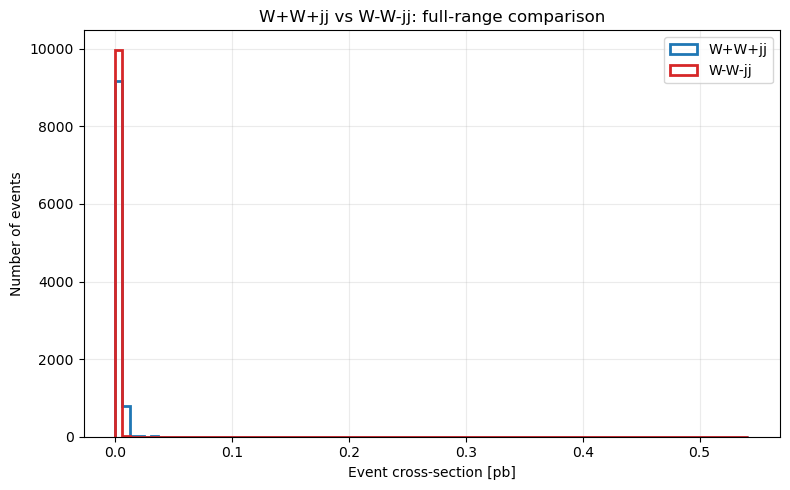


Central 95% window (combined):
  low  = 1.408105e-03 pb
  high = 6.437543e-03 pb
  W+W+jj kept = 9521/10000
  W-W-jj kept = 9479/10000


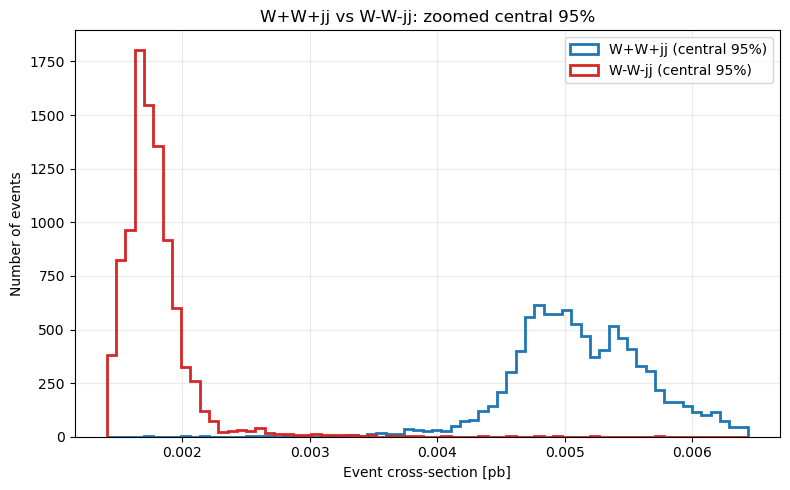

In [ ]:
# ==========================================
# Cross-section distribution from all HepMC events
# ==========================================

def collect_event_xsecs_from_dir(hepmc_dir, label):
    hepmc_files = sorted(glob.glob(f"{hepmc_dir}/*.hepmc"), key=lambda p: os.path.basename(p))

    xsecs = []
    total_events = 0
    missing_xsec = 0
    invalid_xsec = 0

    for hepmc_path in tqdm(hepmc_files, desc=f"Reading {label}"):
        with pyhepmc.open(hepmc_path) as f_hepmc:
            for event in f_hepmc:
                total_events += 1

                if (not event) or (event.cross_section is None):
                    missing_xsec += 1
                    continue

                try:
                    xsec_pb = float(event.cross_section.xsec(0))
                except Exception:
                    invalid_xsec += 1
                    continue

                if np.isfinite(xsec_pb):
                    xsecs.append(xsec_pb)
                else:
                    invalid_xsec += 1

    return {
        "label": label,
        "n_files": len(hepmc_files),
        "total_events": total_events,
        "valid_events": len(xsecs),
        "missing_xsec": missing_xsec,
        "invalid_xsec": invalid_xsec,
        "xsecs": np.array(xsecs, dtype=float),
    }


sample_hepmc_dirs = [
    ("W+W+jj", "./Sherpa/EW_WpWpjj/hepmc_data"),
    ("W-W-jj", "./Sherpa/EW_WmWmjj/hepmc_data"),
]

xsec_results = [collect_event_xsecs_from_dir(path, label) for label, path in sample_hepmc_dirs]

all_xsecs = np.concatenate([r["xsecs"] for r in xsec_results if r["xsecs"].size > 0])
if all_xsecs.size == 0:
    raise RuntimeError("No valid event cross-section found in the selected HepMC directories.")

xsec_by_label = {r["label"]: r["xsecs"] for r in xsec_results}
xsec_wp = xsec_by_label.get("W+W+jj", np.array([], dtype=float))
xsec_wm = xsec_by_label.get("W-W-jj", np.array([], dtype=float))

if xsec_wp.size == 0 or xsec_wm.size == 0:
    raise RuntimeError("Need valid xsec arrays for both W+W+jj and W-W-jj to draw comparison plots.")

print("=" * 90)
print("HepMC event-level cross-section summary (unit: pb)")
print("=" * 90)
print(f"{'Sample':<12} {'Files':>8} {'Events':>12} {'Valid':>12} {'Missing':>12} {'Invalid':>12}")
print("-" * 90)
for r in xsec_results:
    print(
        f"{r['label']:<12} {r['n_files']:>8} {r['total_events']:>12} "
        f"{r['valid_events']:>12} {r['missing_xsec']:>12} {r['invalid_xsec']:>12}"
    )
print("-" * 90)
print(f"{'Combined':<12} {'':>8} {sum(r['total_events'] for r in xsec_results):>12} {all_xsecs.size:>12}")

print("\nCombined statistics:")
print(f"  min    = {all_xsecs.min():.6e} pb")
print(f"  max    = {all_xsecs.max():.6e} pb")
print(f"  mean   = {all_xsecs.mean():.6e} pb")
print(f"  median = {np.median(all_xsecs):.6e} pb")
print(f"  std    = {all_xsecs.std():.6e} pb")

# 圖 1: 完整範圍比較
fig, ax = plt.subplots(figsize=(8, 5))
bins_full = np.linspace(all_xsecs.min(), all_xsecs.max(), 90)
ax.hist(xsec_wp, bins=bins_full, histtype="step", linewidth=2.0, color="#1f77b4", label="W+W+jj")
ax.hist(xsec_wm, bins=bins_full, histtype="step", linewidth=2.0, color="#d62728", label="W-W-jj")
ax.set_xlabel("Event cross-section [pb]")
ax.set_ylabel("Number of events")
ax.set_title("W+W+jj vs W-W-jj: full-range comparison")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 圖 2: central 95% 放大比較（去除兩端各 2.5% 尾巴）
q_low, q_high = np.quantile(all_xsecs, [0.025, 0.975])
xsec_wp_c95 = xsec_wp[(xsec_wp >= q_low) & (xsec_wp <= q_high)]
xsec_wm_c95 = xsec_wm[(xsec_wm >= q_low) & (xsec_wm <= q_high)]

print("\nCentral 95% window (combined):")
print(f"  low  = {q_low:.6e} pb")
print(f"  high = {q_high:.6e} pb")
print(f"  W+W+jj kept = {xsec_wp_c95.size}/{xsec_wp.size}")
print(f"  W-W-jj kept = {xsec_wm_c95.size}/{xsec_wm.size}")

fig, ax = plt.subplots(figsize=(8, 5))
bins_zoom = np.linspace(q_low, q_high, 70)
ax.hist(xsec_wp_c95, bins=bins_zoom, histtype="step", linewidth=2.0, color="#1f77b4", label="W+W+jj (central 95%)")
ax.hist(xsec_wm_c95, bins=bins_zoom, histtype="step", linewidth=2.0, color="#d62728", label="W-W-jj (central 95%)")
ax.set_xlabel("Event cross-section [pb]")
ax.set_ylabel("Number of events")
ax.set_title("W+W+jj vs W-W-jj: zoomed central 95%")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Sherpa kinematic distributions (獨立版本)

此段為**完全獨立實作**，直接用 Sherpa 的 `hepmc_data` + `delphes_root` 同步讀檔：

- 不使用、也不參考 `Sh_parton.py`
- 不使用、也不參考 `MG_parton.py`

輸出變數：

- `deta_ll = |eta_l1 - eta_l2|`
- `dphi_jj = |DeltaPhi(j1,j2)|`
- `mT = sqrt((Et_ll + MET)^2 - (px_tot^2 + py_tot^2))`

並用 COM frame 的 `Unpol / LL / LT / TT` 權重畫 normalized kinematic distributions。

In [ ]:
import os
import glob
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm


def sherpa_extract_com_weights(hepmc_event):
    w_dict = dict(zip(hepmc_event.weight_names, hepmc_event.weights))
    w_nom = float(w_dict.get("Weight", 1.0))

    has_w_plus = any("W+" in n for n in hepmc_event.weight_names)
    if has_w_plus:
        w_ll = float(w_dict.get("PolWeight_COM.W+.0_W+.0", 0.0))
        w_lt = float(w_dict.get("PolWeight_COM.W+.0_W+.T", 0.0)) + float(w_dict.get("PolWeight_COM.W+.T_W+.0", 0.0))
        w_tt = float(w_dict.get("PolWeight_COM.W+.T_W+.T", 0.0))
    else:
        w_ll = float(w_dict.get("PolWeight_COM.W-.0_W-.0", 0.0))
        w_lt = float(w_dict.get("PolWeight_COM.W-.0_W-.T", 0.0)) + float(w_dict.get("PolWeight_COM.W-.T_W-.0", 0.0))
        w_tt = float(w_dict.get("PolWeight_COM.W-.T_W-.T", 0.0))

    return {"Unpol": w_nom, "LL": w_ll, "LT": w_lt, "TT": w_tt}


def sherpa_pass_sr_and_kinematics(tree):
    stage, sr_objects = pass_SR_cuts(tree, return_objects=True)
    if stage < 3:
        return None

    leptons = sr_objects["leptons"]
    l1, l2 = leptons[0], leptons[1]
    ll_p4 = sr_objects["ll_p4"]
    met = sr_objects["met"]
    jets = sr_objects["jets"]
    j1, j2 = jets[0], jets[1]

    deta_ll = abs(l1["p4"].Eta() - l2["p4"].Eta())
    dphi_jj = abs(j1.DeltaPhi(j2))

    met_px = met.MET * np.cos(met.Phi)
    met_py = met.MET * np.sin(met.Phi)
    et_ll = np.sqrt(ll_p4.Pt() ** 2 + ll_p4.M() ** 2)
    px_tot = ll_p4.Px() + met_px
    py_tot = ll_p4.Py() + met_py
    mT_sq = (et_ll + met.MET) ** 2 - (px_tot ** 2 + py_tot ** 2)
    mT = np.sqrt(mT_sq) if mT_sq > 0 else 0.0

    return {"deta_ll": deta_ll, "dphi_jj": dphi_jj, "mT": mT}


def _empty_pol_dict():
    return {
        "Unpol": {"deta_ll": [], "dphi_jj": [], "mT": [], "w": []},
        "LL": {"deta_ll": [], "dphi_jj": [], "mT": [], "w": []},
        "LT": {"deta_ll": [], "dphi_jj": [], "mT": [], "w": []},
        "TT": {"deta_ll": [], "dphi_jj": [], "mT": [], "w": []},
    }


def _process_single_pair(hepmc_path, root_path):
    local = _empty_pol_dict()

    f_root = ROOT.TFile(root_path)
    tree = f_root.Get("Delphes")
    if not tree:
        f_root.Close()
        return local

    n_root = tree.GetEntries()

    with pyhepmc.open(hepmc_path) as f_hepmc:
        for i, hepmc_event in enumerate(f_hepmc):
            if i >= n_root:
                break

            tree.GetEntry(i)
            kin = sherpa_pass_sr_and_kinematics(tree)
            if kin is None:
                continue

            w = sherpa_extract_com_weights(hepmc_event)
            for pol in ["Unpol", "LL", "LT", "TT"]:
                local[pol]["deta_ll"].append(kin["deta_ll"])
                local[pol]["dphi_jj"].append(kin["dphi_jj"])
                local[pol]["mT"].append(kin["mT"])
                local[pol]["w"].append(w[pol])

    f_root.Close()
    return local


def sherpa_collect_kinematics(hepmc_dir, root_dir, label="sample", max_files=None, workers=None):
    out = _empty_pol_dict()

    hepmc_files = sorted(glob.glob(f"{hepmc_dir}/*.hepmc"), key=lambda p: os.path.basename(p))
    if max_files is not None:
        hepmc_files = hepmc_files[:max_files]

    pairs = []
    for hepmc_path in hepmc_files:
        base = os.path.basename(hepmc_path).replace(".hepmc", "")
        root_path = f"{root_dir}/{base}.root"
        if os.path.exists(root_path):
            pairs.append((hepmc_path, root_path))

    if len(pairs) == 0:
        print(f"[{label}] no matched HepMC/ROOT pairs found.")
        for pol in out:
            for key in ["deta_ll", "dphi_jj", "mT", "w"]:
                out[pol][key] = np.array([], dtype=float)
        return out

    max_cpu = os.cpu_count() or 1
    if workers is None:
        workers = max(1, max_cpu // 2)
    workers = max(1, min(int(workers), len(pairs)))

    print(f"[{label}] matched file pairs: {len(pairs)}, workers: {workers}")

    if workers == 1:
        iterator = pairs
        for hepmc_path, root_path in tqdm(iterator, desc=f"[{label}] filtering", total=len(pairs)):
            part = _process_single_pair(hepmc_path, root_path)
            for pol in ["Unpol", "LL", "LT", "TT"]:
                for key in ["deta_ll", "dphi_jj", "mT", "w"]:
                    out[pol][key].extend(part[pol][key])
    else:
        with concurrent.futures.ProcessPoolExecutor(max_workers=workers) as executor:
            futures = {
                executor.submit(_process_single_pair, hepmc_path, root_path): (hepmc_path, root_path)
                for hepmc_path, root_path in pairs
            }
            for fut in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc=f"[{label}] filtering"):
                try:
                    part = fut.result()
                except Exception as exc:
                    hepmc_path, _ = futures[fut]
                    print(f"[{label}] skip {os.path.basename(hepmc_path)} due to worker error: {exc}")
                    continue

                for pol in ["Unpol", "LL", "LT", "TT"]:
                    for key in ["deta_ll", "dphi_jj", "mT", "w"]:
                        out[pol][key].extend(part[pol][key])

    for pol in out:
        for key in ["deta_ll", "dphi_jj", "mT", "w"]:
            out[pol][key] = np.array(out[pol][key], dtype=float)

    return out


def _norm_hist(x, w, bins, hrange):
    if x.size == 0 or w.size == 0:
        return np.zeros(bins), np.linspace(hrange[0], hrange[1], bins + 1)
    h, e = np.histogram(x, bins=bins, range=hrange, weights=w)
    s = np.sum(h)
    if s > 0:
        h = h / s
    return h, e


def plot_sherpa_atlas_variable(ax_main, ax_ratio, data_dict, var_key, bins, val_range, xlabel, ymax):
    hist = {}
    edges = None
    for pol in ["LL", "LT", "TT", "Unpol"]:
        h, e = _norm_hist(data_dict[pol][var_key], data_dict[pol]["w"], bins, val_range)
        hist[pol] = h
        edges = e

    centers = (edges[:-1] + edges[1:]) / 2

    styles = {
        "Unpol": {"color": "#000000", "linestyle": "solid", "label": "Unpolarized"},
        "LL": {"color": "#7EBC42", "linestyle": "solid", "label": r"$W_L^{\pm}W_L^{\pm}jj$-EW"},
        "LT": {"color": "#E63928", "linestyle": "dashed", "label": r"$W_L^{\pm}W_T^{\pm}jj$-EW"},
        "TT": {"color": "#3378FF", "linestyle": "dotted", "label": r"$W_T^{\pm}W_T^{\pm}jj$-EW"},
    }

    # for pol in ["Unpol", "LL", "LT", "TT"]:
    for pol in ["LL", "LT", "TT"]:
        ax_main.hist(
            centers,
            bins=edges,
            weights=hist[pol],
            histtype="step",
            linewidth=2.5,
            color=styles[pol]["color"],
            linestyle=styles[pol]["linestyle"],
            label=styles[pol]["label"],
        )

    ax_main.set_xlim(val_range)
    ax_main.set_ylim(0, ymax)
    ax_main.set_ylabel("Normalized distribution", fontsize=14)
    ax_main.tick_params(axis="x", labelbottom=False)
    ax_main.tick_params(axis="both", which="major", direction="in", length=8, width=1.2, top=True, right=True)
    ax_main.tick_params(axis="both", which="minor", direction="in", length=4, width=1.0, top=True, right=True)
    ax_main.minorticks_on()
    ax_main.legend(frameon=False, loc="upper right", fontsize=11)

    hist_total = hist["LL"] + hist["LT"] + hist["TT"]
    safe_total = np.where(hist_total == 0, 1e-12, hist_total)

    ratio_ll = hist["LL"] / safe_total
    ratio_lt = hist["LT"] / safe_total
    ratio_tt = hist["TT"] / safe_total

    ax_ratio.stairs(ratio_ll, edges=edges, color=styles["LL"]["color"], linewidth=2, linestyle=styles["LL"]["linestyle"])
    ax_ratio.stairs(ratio_lt, edges=edges, color=styles["LT"]["color"], linewidth=2, linestyle=styles["LT"]["linestyle"])
    ax_ratio.stairs(ratio_tt, edges=edges, color=styles["TT"]["color"], linewidth=2, linestyle=styles["TT"]["linestyle"])
    ax_ratio.axhline(1.0, color="black", linewidth=1.5)

    ax_ratio.set_xlim(val_range)
    ax_ratio.set_ylim(0, 2.0)
    ax_ratio.set_xlabel(xlabel, fontsize=14)
    ax_ratio.set_ylabel(r"$\frac{\mathrm{Norm(pol.)}}{\mathrm{Norm(total)}}$", fontsize=14, labelpad=10)
    ax_ratio.set_yticks([0.5, 1.0, 1.5])
    ax_ratio.tick_params(axis="both", which="major", direction="in", length=8, width=1.2, top=True, right=True)
    ax_ratio.tick_params(axis="both", which="minor", direction="in", length=4, width=1.0, top=True, right=True)
    ax_ratio.minorticks_on()


def plot_sherpa_atlas_style(data_dict, save_dir="../figures", tag="Sherpa_WWjj"):
    variables = [
        {"key": "deta_ll", "bins": 20, "range": (0, 5.0), "xlabel": r"$\Delta\eta_{\ell\ell}$", "ymax": 0.23, "filename": "deta_ll"},
        {"key": "mT", "bins": 20, "range": (0, 1000), "xlabel": r"$m_T$ [GeV]", "ymax": 0.46, "filename": "mT"},
        {"key": "dphi_jj", "bins": 20, "range": (0, np.pi), "xlabel": r"$\Delta\phi_{jj}$", "ymax": 0.24, "filename": "dphi_jj"},
    ]

    os.makedirs(save_dir, exist_ok=True)

    for var in variables:
        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 1, height_ratios=[7, 3], hspace=0.00)
        ax_main = fig.add_subplot(gs[0])
        ax_ratio = fig.add_subplot(gs[1])

        plot_sherpa_atlas_variable(
            ax_main=ax_main,
            ax_ratio=ax_ratio,
            data_dict=data_dict,
            var_key=var["key"],
            bins=var["bins"],
            val_range=var["range"],
            xlabel=var["xlabel"],
            ymax=var["ymax"],
        )

        out_pdf = f"{save_dir}/{tag}_{var['filename']}.pdf"

        plt.savefig(out_pdf, bbox_inches="tight", dpi=300)

        plt.show()
        plt.close()

        print(f"saved: {out_pdf}")

[W+W+jj] matched file pairs: 100, workers: 48


[W+W+jj] filtering: 100%|██████████| 100/100 [00:15<00:00,  6.38it/s]

[W-W-jj] matched file pairs: 100, workers: 48



[W-W-jj] filtering: 100%|██████████| 100/100 [00:16<00:00,  6.12it/s]


events after SR cuts:
  Unpol : 42818
  LL    : 42818
  LT    : 42818
  TT    : 42818


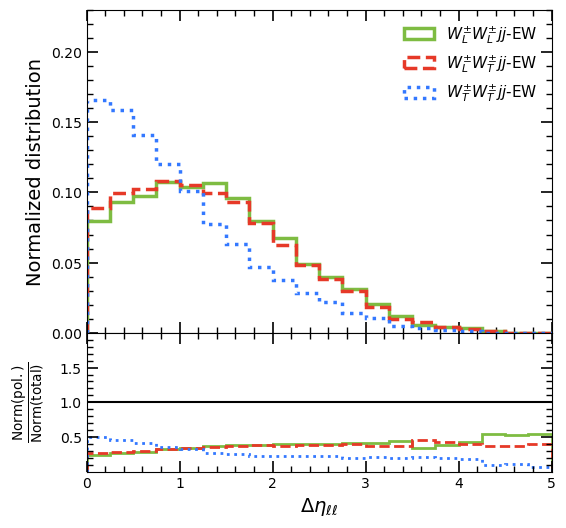

saved: ../figures/EW_WWjj_sherpa_com_deta_ll.pdf


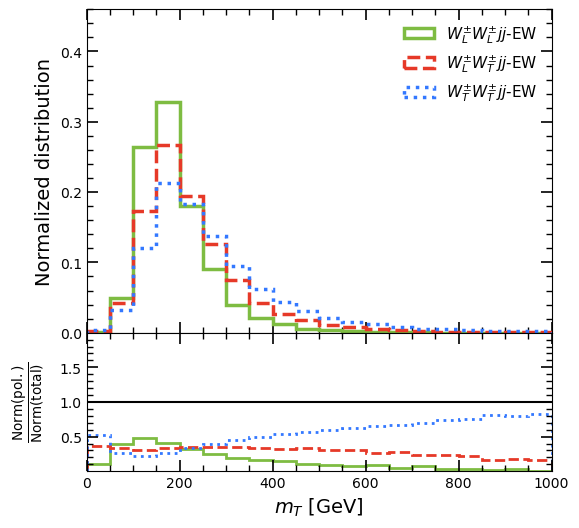

saved: ../figures/EW_WWjj_sherpa_com_mT.pdf


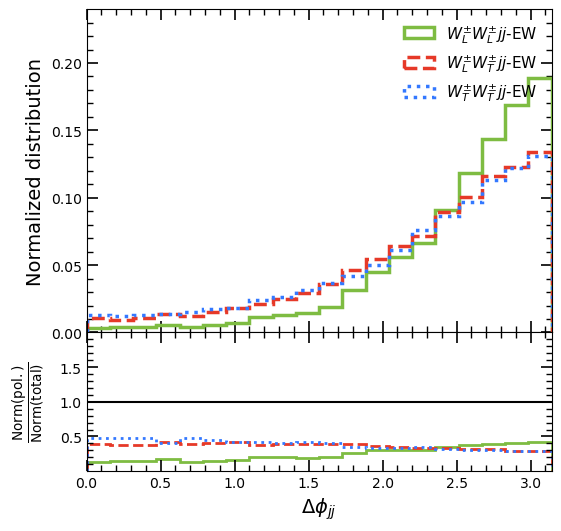

saved: ../figures/EW_WWjj_sherpa_com_dphi_jj.pdf


In [5]:
# 執行：WpWp + WmWm 合併後畫圖（MadGraph 同版型）

WpWpjj_hepmc_dir = './Sherpa/EW_WpWpjj/hepmc_data'
WpWpjj_root_dir = './Sherpa/EW_WpWpjj/delphes_root'
WmWmjj_hepmc_dir = './Sherpa/EW_WmWmjj/hepmc_data'
WmWmjj_root_dir = './Sherpa/EW_WmWmjj/delphes_root'

# 可手動指定核心數；None 代表自動使用約半數 CPU
N_KINEMATICS_WORKERS = max(1, (os.cpu_count() or 1) // 2)

# 若要快速測試可設 max_files=2；完整跑請設 None
wp_data = sherpa_collect_kinematics(
    hepmc_dir=WpWpjj_hepmc_dir,
    root_dir=WpWpjj_root_dir,
    label='W+W+jj',
    max_files=None,
    workers=N_KINEMATICS_WORKERS,
)

wm_data = sherpa_collect_kinematics(
    hepmc_dir=WmWmjj_hepmc_dir,
    root_dir=WmWmjj_root_dir,
    label='W-W-jj',
    max_files=None,
    workers=N_KINEMATICS_WORKERS,
)

combined = {}
for pol in ['Unpol', 'LL', 'LT', 'TT']:
    combined[pol] = {
        'deta_ll': np.concatenate([wp_data[pol]['deta_ll'], wm_data[pol]['deta_ll']]),
        'dphi_jj': np.concatenate([wp_data[pol]['dphi_jj'], wm_data[pol]['dphi_jj']]),
        'mT': np.concatenate([wp_data[pol]['mT'], wm_data[pol]['mT']]),
        'w': np.concatenate([wp_data[pol]['w'], wm_data[pol]['w']]),
    }

print('events after SR cuts:')
for pol in ['Unpol', 'LL', 'LT', 'TT']:
    print(f"  {pol:<6}: {combined[pol]['mT'].size}")

plot_sherpa_atlas_style(
    combined,
    save_dir='../figures',
    tag='EW_WWjj_sherpa_com',
)

# Background

In [6]:
def compute_expected_events_by_region_parallel(sample_inputs, luminosity_fb_inv=139.0, num_workers=None, chunks_per_file=1):
    """Parallel background analysis using the shared selection parallel core."""
    results = {}
    sample_groups = {sample_name: [paths['root']] for sample_name, paths in sample_inputs.items()}

    print("[Background] Processing all samples with file + chunk parallelism...\n")
    sr_results_parallel = selection_cut_parallel(
        sample_groups=sample_groups,
        cut_func_name='pass_SR_cuts',
        num_workers=num_workers,
        chunks_per_file=chunks_per_file,
    )
    low_mjj_results_parallel = selection_cut_parallel(
        sample_groups=sample_groups,
        cut_func_name='pass_low_mjj_cr_cuts',
        num_workers=num_workers,
        chunks_per_file=chunks_per_file,
    )
    wz_results_parallel = selection_cut_parallel(
        sample_groups=sample_groups,
        cut_func_name='pass_WZ_CR_cuts',
        num_workers=num_workers,
        chunks_per_file=chunks_per_file,
    )

    for sample_name, paths in sample_inputs.items():
        sigma_gen_fb = get_cross_section_from_MG5(paths['banner'])
        sr = sr_results_parallel[sample_name]
        low_mjj = low_mjj_results_parallel[sample_name]
        wz = wz_results_parallel[sample_name]

        n_total = sr['cutflow']['Total']
        acc_sr = sr['cutflow']['Jet cut'] / n_total if n_total > 0 else 0.0
        acc_low_mjj = low_mjj['cutflow']['Jet cut'] / n_total if n_total > 0 else 0.0
        acc_wz = wz['cutflow']['Jet cut'] / n_total if n_total > 0 else 0.0

        sigma_sr_fb = sigma_gen_fb * acc_sr
        sigma_low_mjj_fb = sigma_gen_fb * acc_low_mjj
        sigma_wz_fb = sigma_gen_fb * acc_wz

        results[sample_name] = {
            'sigma_gen_fb': sigma_gen_fb,
            'sigma_sr_fb': sigma_sr_fb,
            'sigma_low_mjj_fb': sigma_low_mjj_fb,
            'sigma_wz_fb': sigma_wz_fb,
            'n_expected_sr': sigma_sr_fb * luminosity_fb_inv,
            'n_expected_low_mjj': sigma_low_mjj_fb * luminosity_fb_inv,
            'n_expected_wz': sigma_wz_fb * luminosity_fb_inv,
        }

    return results

In [7]:
sample_inputs = {
    'WWjj_EW-NWA': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_EW-NWA/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_EW-NWA/Events/run_01/run_01_tag_1_banner.txt',
    },
    'WWjj_QCD-NWA': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_QCD-NWA/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_QCD-NWA/Events/run_01/run_01_tag_1_banner.txt',
    },
    'WZjj_EW-NWA': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_EW-NWA/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_EW-NWA/Events/run_01/run_01_tag_1_banner.txt',
    },
    'WZjj_QCD-NWA': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_QCD-NWA/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_QCD-NWA/Events/run_01/run_01_tag_1_banner.txt',
    },

    # 'WZjj_EW-JY': {
    #     'root': '/home/public/WZjj_JY_260409/WZ_EW/tag_1_delphes_events.root',
    #     'banner': '/home/public/WZjj_JY_260409/WZ_EW/run_01_tag_1_banner.txt',
    # },
    # 'WZjj_QCD-JY': {
    #     'root': '/home/public/WZjj_JY_260409/WZ_QCD/delphes_events.root',
    #     'banner': '/home/public/WZjj_JY_260409/WZ_QCD/run_01_tag_1_banner.txt',
    # },
}

luminosity_fb_inv = 139.0
results = compute_expected_events_by_region_parallel(
    sample_inputs=sample_inputs,
    luminosity_fb_inv=luminosity_fb_inv,
    num_workers=None,
    chunks_per_file=16,
)

[Background] Processing all samples with file + chunk parallelism...


[1/4] WWjj_EW-NWA: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WWjj_EW-NWA: 100%|██████████| 16/16 [00:01<00:00, 13.78it/s]


  ✓ [WWjj_EW-NWA] done → Total=10000 events, passed=3152

[2/4] WWjj_QCD-NWA: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WWjj_QCD-NWA: 100%|██████████| 16/16 [00:01<00:00, 12.65it/s]


  ✓ [WWjj_QCD-NWA] done → Total=10000 events, passed=1358

[3/4] WZjj_EW-NWA: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


...

    WZjj_EW-NWA: 100%|██████████| 16/16 [00:01<00:00, 14.03it/s]


  ✓ [WZjj_EW-NWA] done → Total=10000 events, passed=900

[4/4] WZjj_QCD-NWA: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WZjj_QCD-NWA: 100%|██████████| 16/16 [00:01<00:00, 13.98it/s]


  ✓ [WZjj_QCD-NWA] done → Total=10000 events, passed=487


Warning in <TStreamerInfo::BuildCheck>: 
   The StreamerInfo of class Track read from file /home/r10222035/longitudinal_W/Sample/MG5/WWjj_EW-NWA/Events/run_01/tag_1_delphes_events.root
   has the same version (=3) as the active class but a different checksum.
   You should update the version to ClassDef(Track,4).
   Do not try to write objects with the current class definition,
   the files will not be readable.

Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float C; //
Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float Mass; //
Warning in <TStreamerInfo::CompareContent>: The following data member of
the in-memory layout version 3 of class 'Track' is missing from 
the on-file layout version 3:
   float EtaOuter; //
Warning in <TStreamerInf

In [8]:
print(f'Expected event counts comparison table (L = {luminosity_fb_inv:.0f} fb⁻¹)')
print('=' * 75)
print(f"{'Sample':<16} {'N_exp(SR)':>15} {'N_exp(Low-mjj CR)':>19} {'N_exp(WZ CR)':>15}")
print('-' * 75)
for sample_name, vals in sorted(results.items()):
    print(
        f"{sample_name:<16} "
        f"{vals['n_expected_sr']:>15.2f} "
        f"{vals['n_expected_low_mjj']:>19.2f} "
        f"{vals['n_expected_wz']:>15.2f}"
    )

print('-' * 75)
sum_n_sr = sum(v['n_expected_sr'] for v in results.values())
sum_n_low_mjj = sum(v['n_expected_low_mjj'] for v in results.values())
sum_n_wz = sum(v['n_expected_wz'] for v in results.values())

print(
    f"{'SUM':<16} "
    f"{sum_n_sr:>15.2f} "
    f"{sum_n_low_mjj:>19.2f} "
    f"{sum_n_wz:>15.2f}"
)

Expected event counts comparison table (L = 139 fb⁻¹)
Sample                 N_exp(SR)   N_exp(Low-mjj CR)    N_exp(WZ CR)
---------------------------------------------------------------------------
WWjj_EW-NWA               177.98               23.60            0.00
WWjj_QCD-NWA               14.38                7.87            0.00
WZjj_EW-NWA                 9.12                1.44           13.80
WZjj_QCD-NWA               18.47               11.46           36.71
---------------------------------------------------------------------------
SUM                       219.96               44.37           50.51


In [9]:
# v370 Expected event counts comparision table
sample_inputs_v370 = {
    'WWjj_EW-NWA-v370': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_EW-NWA-v370/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_EW-NWA-v370/Events/run_01/run_01_tag_1_banner.txt',
    },
    'WWjj_QCD-NWA-v370': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_QCD-NWA-v370/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WWjj_QCD-NWA-v370/Events/run_01/run_01_tag_1_banner.txt',
    },
    'WZjj_EW-NWA-v370': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_EW-NWA-v370/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_EW-NWA-v370/Events/run_01/run_01_tag_1_banner.txt',
    },
    'WZjj_QCD-NWA-v370': {
        'root': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_QCD-NWA-v370/Events/run_01/tag_1_delphes_events.root',
        'banner': '/home/r10222035/longitudinal_W/Sample/MG5/WZjj_QCD-NWA-v370/Events/run_01/run_01_tag_1_banner.txt',
    },
}

luminosity_fb_inv = 139.0
results_v370 = compute_expected_events_by_region_parallel(
    sample_inputs=sample_inputs_v370,
    luminosity_fb_inv=luminosity_fb_inv,
    num_workers=None,
    chunks_per_file=16,
)

[Background] Processing all samples with file + chunk parallelism...


[1/4] WWjj_EW-NWA-v370: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WWjj_EW-NWA-v370: 100%|██████████| 16/16 [00:01<00:00, 12.37it/s]


  ✓ [WWjj_EW-NWA-v370] done → Total=10000 events, passed=3360

[2/4] WWjj_QCD-NWA-v370: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WWjj_QCD-NWA-v370: 100%|██████████| 16/16 [00:01<00:00, 12.79it/s]


  ✓ [WWjj_QCD-NWA-v370] done → Total=10000 events, passed=1228

[3/4] WZjj_EW-NWA-v370: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


...

  ✓ [WWjj_QCD-NWA-v370] done → Total=10000 events, passed=0

[3/4] WZjj_EW-NWA-v370: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WZjj_EW-NWA-v370: 100%|██████████| 16/16 [00:01<00:00, 13.28it/s]


  ✓ [WZjj_EW-NWA-v370] done → Total=10000 events, passed=882

[4/4] WZjj_QCD-NWA-v370: Processing 1 file(s) with 48 worker(s), 16 chunk(s) per file...


    WZjj_QCD-NWA-v370: 100%|██████████| 16/16 [00:01<00:00, 12.91it/s]

  ✓ [WZjj_QCD-NWA-v370] done → Total=10000 events, passed=462


In [10]:
print(f'Expected event counts comparison table for v370 (L = {luminosity_fb_inv:.0f} fb⁻¹)')
print('=' * 75)
print(f"{'Sample':<20} {'N_exp(SR)':>15} {'N_exp(Low-mjj CR)':>19} {'N_exp(WZ CR)':>15}")
print('-' * 75)
for sample_name, vals in sorted(results_v370.items()):
    print(
        f"{sample_name:<20} "
        f"{vals['n_expected_sr']:>15.2f} "
        f"{vals['n_expected_low_mjj']:>19.2f} "
        f"{vals['n_expected_wz']:>15.2f}"
    )

print('-' * 75)
sum_n_sr = sum(v['n_expected_sr'] for v in results_v370.values())
sum_n_low_mjj = sum(v['n_expected_low_mjj'] for v in results_v370.values())
sum_n_wz = sum(v['n_expected_wz'] for v in results_v370.values())

print(
    f"{'SUM':<20} "
    f"{sum_n_sr:>15.2f} "
    f"{sum_n_low_mjj:>19.2f} "
    f"{sum_n_wz:>15.2f}"
)

Expected event counts comparison table for v370 (L = 139 fb⁻¹)
Sample                     N_exp(SR)   N_exp(Low-mjj CR)    N_exp(WZ CR)
---------------------------------------------------------------------------
WWjj_EW-NWA-v370              190.28               22.26            0.06
WWjj_QCD-NWA-v370              12.96                8.76            0.00
WZjj_EW-NWA-v370                9.50                1.47           13.51
WZjj_QCD-NWA-v370              16.30               14.06           34.55
---------------------------------------------------------------------------
SUM                           229.04               46.55           48.12
